<a href="https://colab.research.google.com/github/ashiibansal/machine-learning-lab/blob/main/Project/MLProject_HeartDisease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Machine Learning Project**
### **Aim:** Comparitive analysis of predictive capabilities of ML models for Heart Disease Detection

Ashi Bansal - 23FE10CSE00394 & Riddhi Kulshreshtha - 23FE10CSE00560

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import accuracy_score, classification_report

In [2]:
path = 'heart_statlog_cleveland_hungary_final.csv'
df = pd.read_csv(path)

Understanding the data

In [3]:
df.head() #First 5 lines

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


In [4]:
df.tail() #Last 5 values

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
1185,45,1,1,110,264,0,0,132,0,1.2,2,1
1186,68,1,4,144,193,1,0,141,0,3.4,2,1
1187,57,1,4,130,131,0,0,115,1,1.2,2,1
1188,57,0,2,130,236,0,2,174,0,0.0,2,1
1189,38,1,3,138,175,0,0,173,0,0.0,1,0


In [5]:
df.shape # Number of rows and columns in this dataset

(1190, 12)

In [6]:
df.describe()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
count,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000
mean,53.720168,0.763866,3.232773,132.153782,210.363866,0.213445,0.698319,139.732773,0.387395,0.922773,1.624370,0.528571
std,9.358203,0.424884,0.935480,18.368823,101.420489,0.409912,0.870359,25.517636,0.487360,1.086337,0.610459,0.499393
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,188.000000,0.000000,0.000000,121.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,229.000000,0.000000,0.000000,140.500000,0.000000,0.600000,2.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,269.750000,0.000000,2.000000,160.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000


Here, describe() is giving information about the following:
1. count: Number of non null entries in the column
2. mean: Average of the column
3. std: Standard deviation (how spread out the value are)
4. min: Minimum value in the column
5. 25% (Q1): 1st quartile i.e. 25% of the data is below this value
6. 50% (median): Middle value i.e. 50% of the data is below this value
7. 75% (Q3): 3rd quartile i.e. 75% of the data is below this value
8. max: Maximum value in the column

# The values for Q1, median and Q3 are not referring to the starting values. They can be any values from anywhere in the dataset.

**NOTE**: This Q1 and Q3 is used to calculate the IQR (InterQuartile Range) as Q3-Q1 which tells us the spread of middle 50% of our data. It helps with outlier detection. Any outlier is either


*   Less than Q1 - 1.5 * IQR
*   Greater than Q3 + 1.5 * IQR


25% (Q1) ||||||||||   50%

75% (Q3)||||||||||||||||||||||||||||||||||||

Even though the columns sex, chest pain type, fasting blood sugar, resting ecg, excercise angina and ST slope have already numerically encoded values, they are still considered CATEGORICAL FEATURES.

In [7]:
df.nunique() #Total number of unique observations over the index axis

,0
age,50
sex,2
chest pain type,4
resting bp s,67
cholesterol,222
fasting blood sugar,2
resting ecg,3
max heart rate,119
exercise angina,2
oldpeak,53


In [8]:
df['sex'].unique()

array([1, 0])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   int64  
 1   sex                  1190 non-null   int64  
 2   chest pain type      1190 non-null   int64  
 3   resting bp s         1190 non-null   int64  
 4   cholesterol          1190 non-null   int64  
 5   fasting blood sugar  1190 non-null   int64  
 6   resting ecg          1190 non-null   int64  
 7   max heart rate       1190 non-null   int64  
 8   exercise angina      1190 non-null   int64  
 9   oldpeak              1190 non-null   float64
 10  ST slope             1190 non-null   int64  
 11  target               1190 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 111.7 KB


Here we see that sex, chest pain type, fasting blood sugar, resting ecg, excercise angina, ST slope and target are encoded. So their datatype is numerical. But actually they are categorical in nature. So we should convert them into object dtype for better results in EDA.

In [10]:
continuous_features = ['age', 'resting bp s', 'cholesterol', 'max heart rate', 'oldpeak']
features_to_convert = [feature for feature in df.columns if feature not in continuous_features]

# Convert the identified features to object data type
df[features_to_convert] = df[features_to_convert].astype('object')
df.dtypes

,0
age,int64
sex,object
chest pain type,object
resting bp s,int64
cholesterol,int64
fasting blood sugar,object
resting ecg,object
max heart rate,int64
exercise angina,object
oldpeak,float64


In [11]:
df.describe()

,age,resting bp s,cholesterol,max heart rate,oldpeak
count,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000
mean,53.720168,132.153782,210.363866,139.732773,0.922773
std,9.358203,18.368823,101.420489,25.517636,1.086337
min,28.000000,0.000000,0.000000,60.000000,-2.600000
25%,47.000000,120.000000,188.000000,121.000000,0.000000
50%,54.000000,130.000000,229.000000,140.500000,0.600000
75%,60.000000,140.000000,269.750000,160.000000,1.600000
max,77.000000,200.000000,603.000000,202.000000,6.200000


In [12]:

df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1190.0,53.720168,9.358203,28.0,47.0,54.0,60.00,77.0
resting bp s,1190.0,132.153782,18.368823,0.0,120.0,130.0,140.00,200.0
cholesterol,1190.0,210.363866,101.420489,0.0,188.0,229.0,269.75,603.0
max heart rate,1190.0,139.732773,25.517636,60.0,121.0,140.5,160.00,202.0
oldpeak,1190.0,0.922773,1.086337,-2.6,0.0,0.6,1.60,6.2


In [13]:
df.describe(include='object') # Here top tells us about the most frequent value and freq gives the frequency of top value

,sex,chest pain type,fasting blood sugar,resting ecg,exercise angina,ST slope,target
count,1190,1190,1190,1190,1190,1190,1190
unique,2,4,2,3,2,4,2
top,1,4,0,0,0,2,1
freq,909,625,936,684,729,582,629


Steps in Data Analysis / EDA
1. Missing values
2. Explore about Numerical Variables + Distribution
3. Explore about Categorial Variables + Distribution
4. Outliers
5. Finding relationship between independent and dependent features


## STEP 1: MISSING VALUES

In [14]:
df.isnull().sum()

,0
age,0
sex,0
chest pain type,0
resting bp s,0
cholesterol,0
fasting blood sugar,0
resting ecg,0
max heart rate,0
exercise angina,0
oldpeak,0


<Axes: >

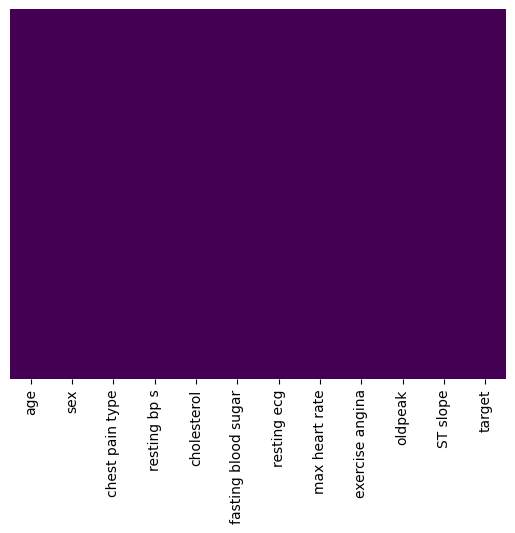

In [15]:
sns.heatmap(df.isnull(), yticklabels = False, cbar = False, cmap = 'viridis')
# Use yticklabels = False to remove row labels/index from yaxis (if too many rows then overcrowded), cbar = False hides colour scale legend (values), cmap is the colour of the map
# Here no missing values

In [16]:
df.target.value_counts() # No imbalance in data (especially for training and cross validation)

,count
target,
1,629
0,561


In [17]:
groups = df.target.value_counts().index
print(groups)

Index([1, 0], dtype='object', name='target')


In [18]:
values = df.target.value_counts().values
print(values)

[629 561]


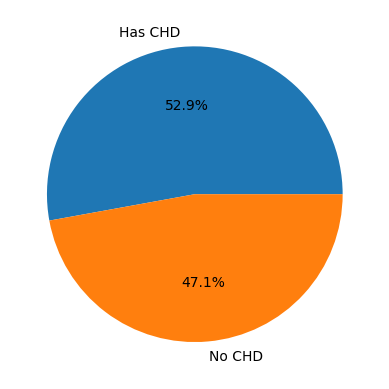

In [19]:
## Creating a pie chart with respect to target variable
plt.pie(values, labels = ['No CHD' if i == 0 else 'Has CHD' for i in groups], autopct = '%1.1f%%')
plt.show()

## This distribution helps us understand that the data is quite balanced.

## STEP 2: NUMERICAL VALUES

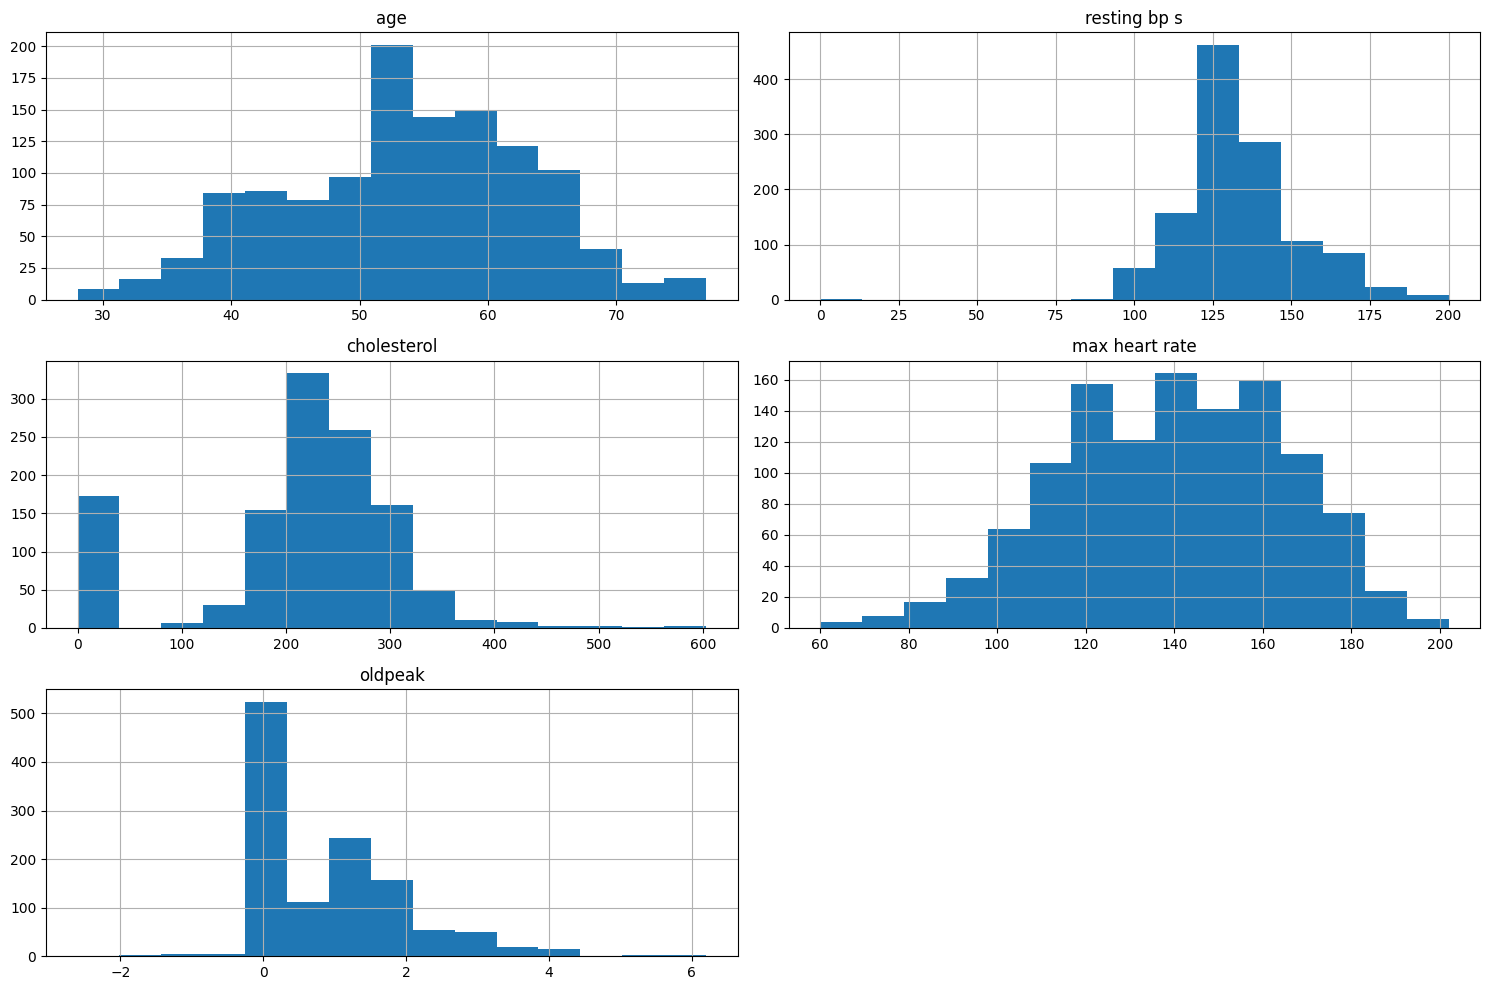

In [20]:
df.hist(bins=15, figsize=(15, 10))
plt.tight_layout()
plt.show()

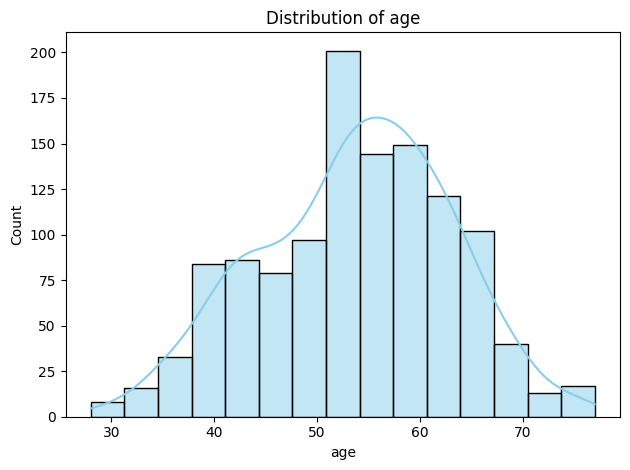

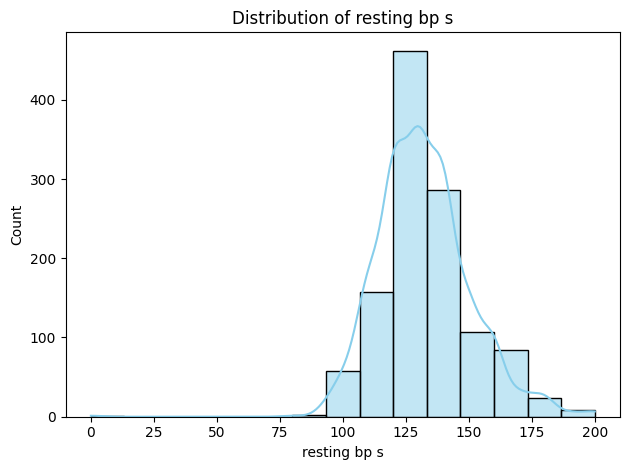

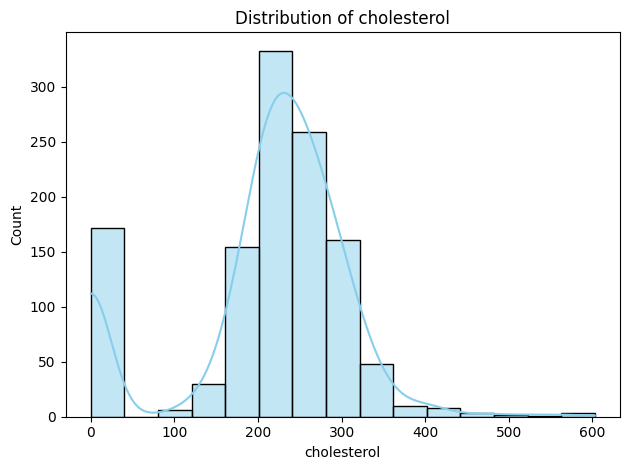

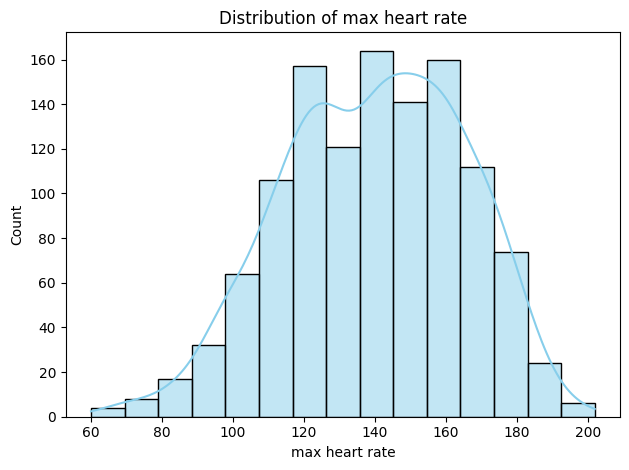

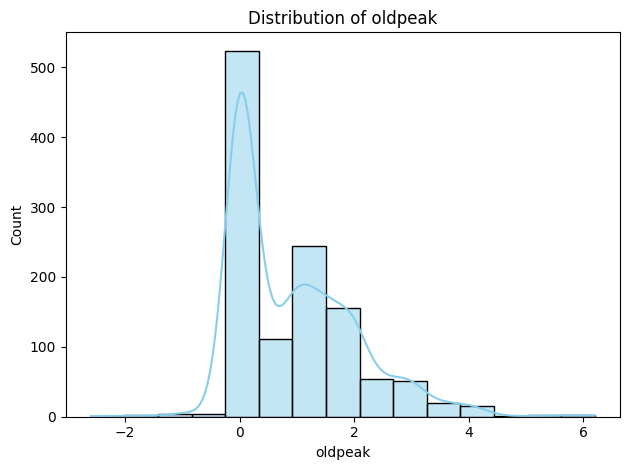

In [21]:
for column in df.select_dtypes(include='number').columns:
    plt.figure()
    sns.histplot(df[column], kde=True, bins=15, color='skyblue', edgecolor='black')
    # kde=True: draws the smooth curve, bins=15: divides the data into 15 bars
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

As 0 cholestrol is not possible. First make the values NaN so that they do not get used while calculating median and then replace them with median.

In [22]:
df['cholesterol'] = df['cholesterol'].replace(0, np.nan)
df['cholesterol'] = df['cholesterol'].fillna(df['cholesterol'].median())

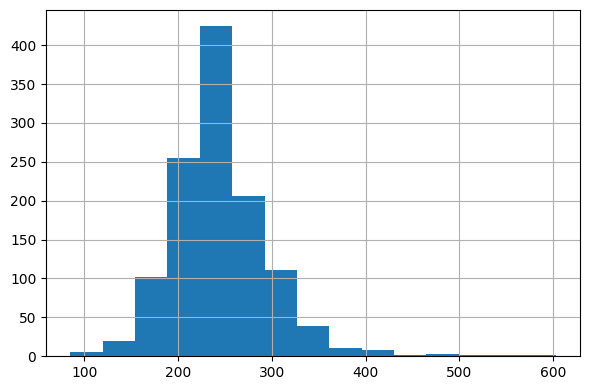

In [23]:
df['cholesterol'].hist(bins=15, figsize=(6, 4))
plt.tight_layout()
plt.show()

For oldpeak, there's a strong right skew with many values at 0. This feature is skewed and can affect models that assume normal distribution. However even after trying various methods to normalize the column there was no fruitful outcome

## STEP 3: CATEGORICAL VALUES

Here the values in categorical features we can see that the features are already encoded (from string to numerical values)

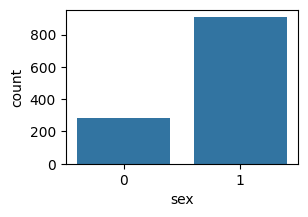

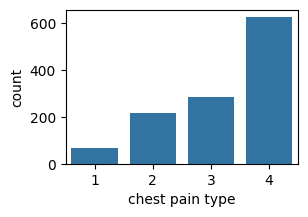

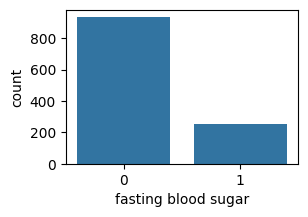

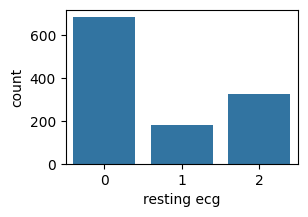

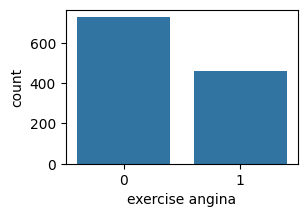

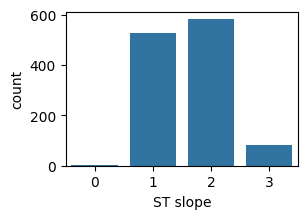

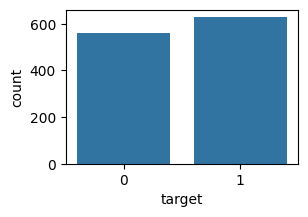

In [24]:
for col in df.select_dtypes(include='object'):
    plt.figure(figsize=(3,2))
    sns.countplot(data=df, x=col)
    plt.show()

## STEP 4: OUTLIERS

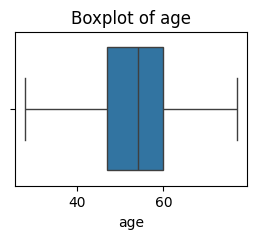

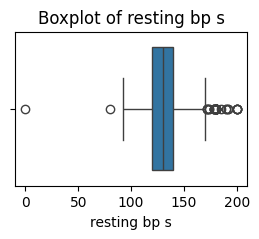

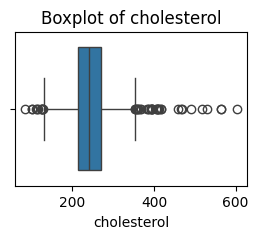

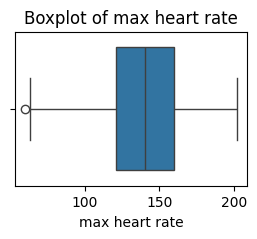

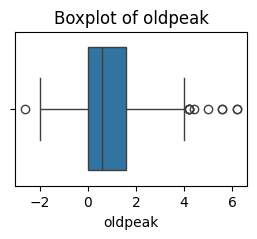

In [25]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    plt.figure(figsize=(3,2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [26]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(col,": ", len(outliers))
    df[col] = np.where(df[col] < lower_bound, lower_bound, np.where(df[col] > upper_bound, upper_bound, df[col]))

age :  0
resting bp s :  37
cholesterol :  44
max heart rate :  1
oldpeak :  11


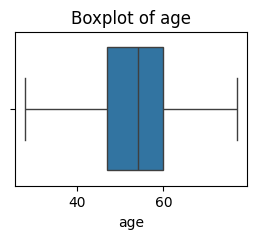

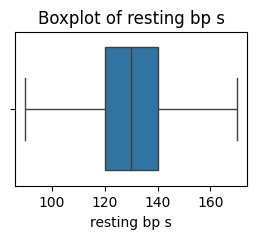

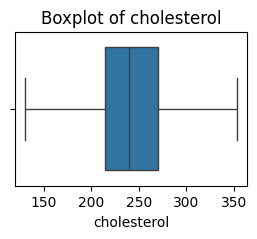

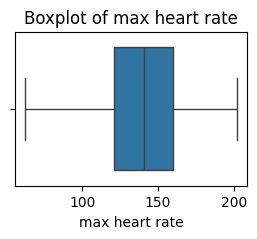

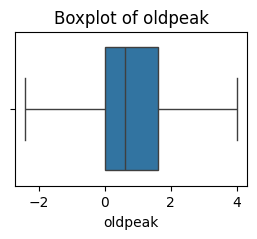

In [27]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    plt.figure(figsize=(3,2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

## STEP 5: CORRELATION

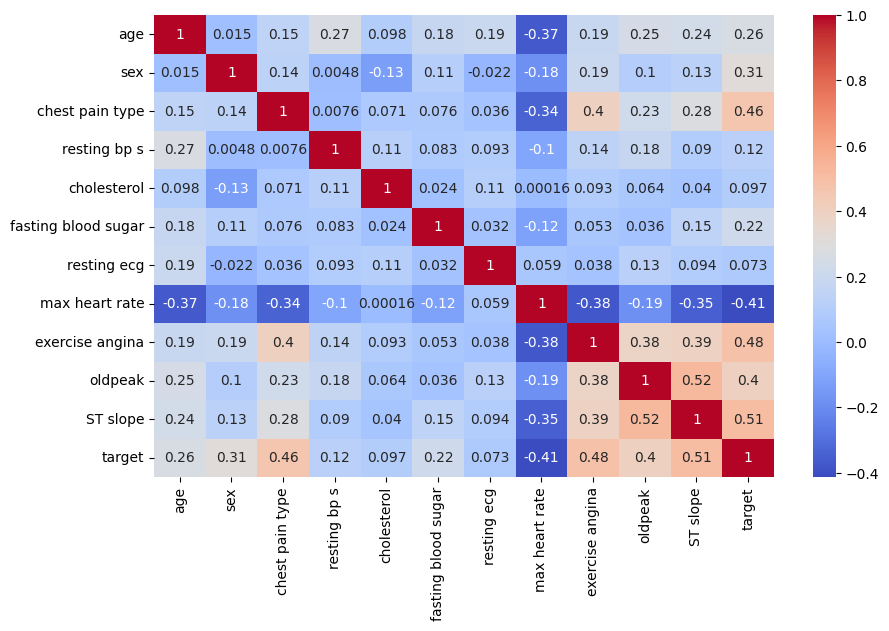

In [28]:
corr_matrix = pd.DataFrame(df, columns=df.columns).corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

Our primary check is to see the correlation of each independent feature with the dependent feature or target.

However in a secondary check we must also see their interconnection. If 2 features are highly correlated (eg., > 0.85) might cause redundancy and in the longer run you may just consider keeping 1 out of those 2 features.

1. chest pain type: 0.46	(Strong positive → more chest pain, higher risk)
2. ST slope:	0.51	(Strong positive)
3. oldpeak:	0.40+	(Strong positive)
4. exercise angina:	0.48	(Strong positive)
5. max heart rate:	-0.41	(Strong negative → lower heart rate, higher risk)

#### Since out of the above chosen columns, oldpeak and max heart rate had outliers that we fixed let us see if the distribution is close to normal so that the spread is dense.

### Upon plotting the graph of the selected numerical features: max heart rate and oldpeak, we see that max heart rate is almost normalised and the remaining skewness can be removed by using Standard Scaler on the numerical training data in the later stages.

#### For oldpeak we need to perform transformation in order to try and remove the extreme right skewness. However even after that the skewness (direction of the tail, not the peak) can not be removed.

In [29]:
##### PERFORMED THIS STEP ONLY IF YOU WANT DATASET FOR AUGUMENTATION STEPS
##### ELSE SKIP THIS STEP AND MOVE TO NEXT CELL FOR NORMAL DATA
df.to_csv('ieee_augumentation.csv', index=False)

In [30]:
# Selected features based on correlation >= 0.40 with target
selected_cols = ['chest pain type', 'ST slope', 'oldpeak', 'exercise angina', 'max heart rate', 'target']

df_selected = df[selected_cols].copy() # Create a new DataFrame
print(df_selected.head()) # Preview the new DataFrame

  chest pain type ST slope  oldpeak exercise angina  max heart rate target
0               2        1      0.0               0           172.0      0
1               3        2      1.0               0           156.0      1
2               2        1      0.0               0            98.0      0
3               4        2      1.5               1           108.0      1
4               3        1      0.0               0           122.0      0


Now we will create a new csv for this cleaned dataset so that we can easily import it while working on various models.

In [31]:
df_selected.to_csv('ieee_selected.csv', index=False) # Save the new DataFrame to a CSV file

In [32]:
path = 'ieee_selected.csv'
df = pd.read_csv(path)

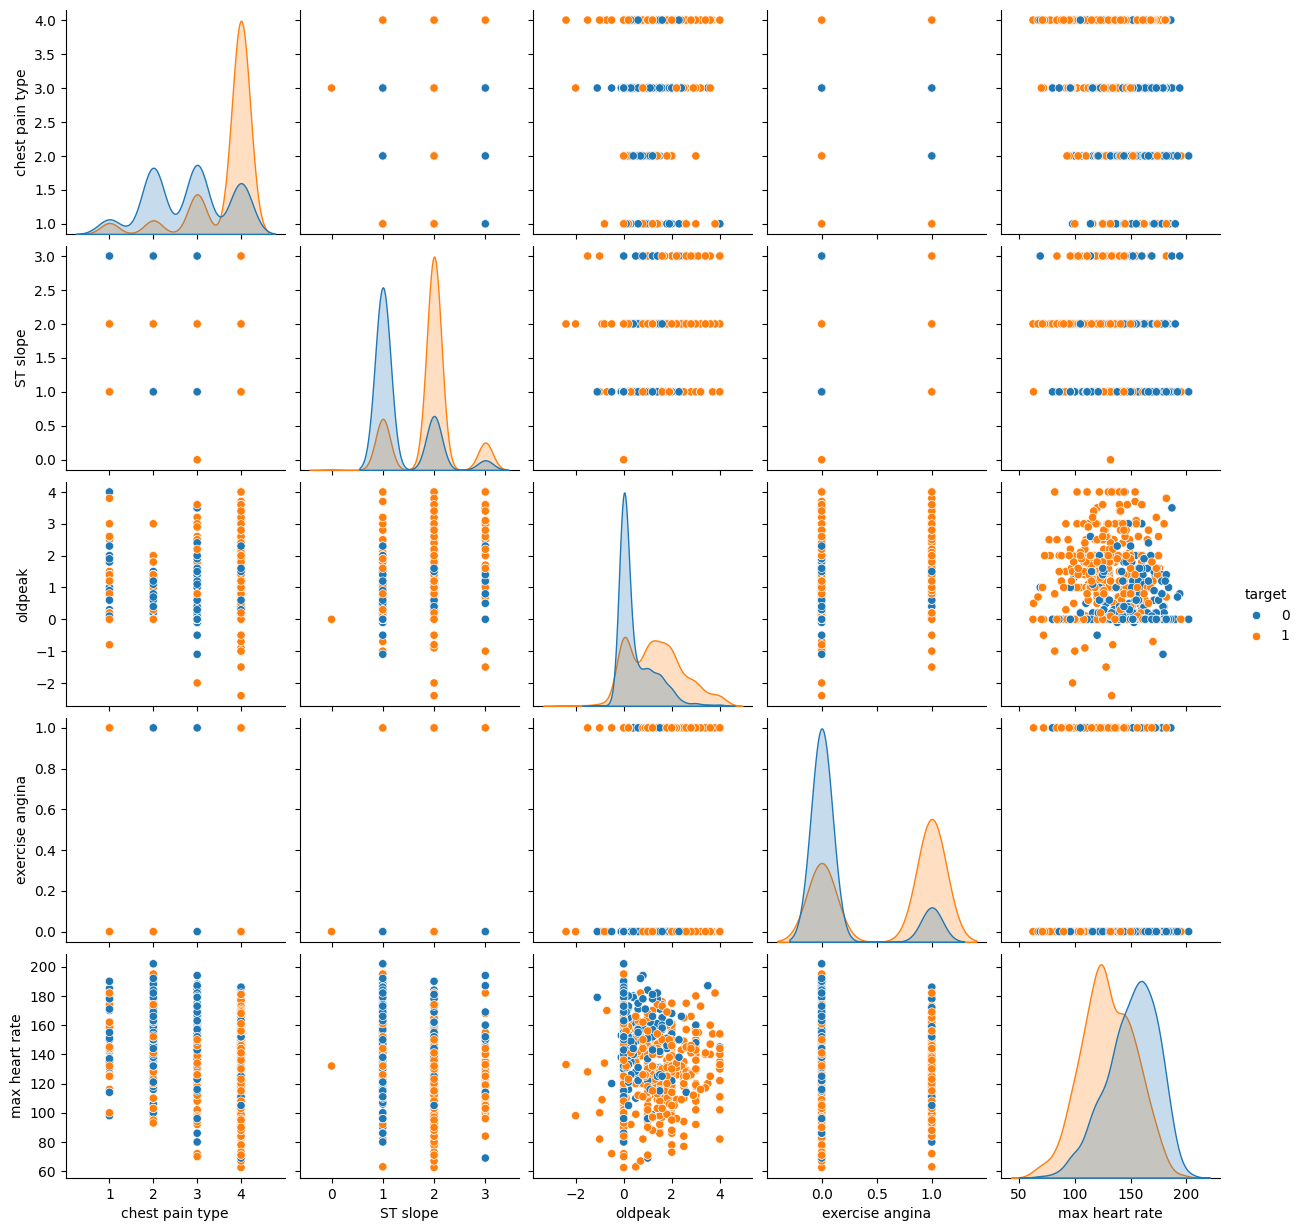

In [33]:
sns.pairplot(df, hue = 'target')

In [34]:
### Splitting the dataset into independent and dependent features
X = df.iloc[:,:-1] # For independent features. Take all columns except the last column
y = df.iloc[:, -1] # For the dependent variable. Just take the last column

In [35]:
X

,chest pain type,ST slope,oldpeak,exercise angina,max heart rate
0,2,1,0.0,0,172.0
1,3,2,1.0,0,156.0
2,2,1,0.0,0,98.0
3,4,2,1.5,1,108.0
4,3,1,0.0,0,122.0
...,...,...,...,...,...
1185,1,2,1.2,0,132.0
1186,4,2,3.4,0,141.0
1187,4,2,1.2,1,115.0
1188,2,2,0.0,0,174.0


In [36]:
y

,target
0,0
1,1
2,0
3,1
4,0
...,...
1185,1
1186,1
1187,1
1188,1


In [37]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)
# We require test data to see how well the model is predicting and what is it's accuracy
# We use random state to shuffle the data before splitting. This avoids any patterns and generates randomness (No trends)

Now we will standardise these values. Why we do so is because different parameters can have different ranges like maximum heart rate achieved is 71 - 202 but another field like exercise angina has small float point values. So we scale them to the same level in order for machine to understand better and not give more weightage to bigger numbers. We try to normalise the data and make it less sparse so that the model parameters find it easier to understand the pattern.

Points to remember while standardising the train and test data
1. Scale them separately to avoid data leakage otherwise the model will already know the data beforehand due to reveal.
2. Use the same scaler to fit both train and test data to avoid unfair results

NOTE: Only standardise X values. If we transform y then they become continuous and instead of classification it changes to a regression problem and our models stop working on it.
_________________________________________

1. In this datatset, exercise angina and max heart rate are numerical featuers so they are scaled using standard scaler.

2. Exercise angina only has 2 values 0 and 1 so it is already encoded.

3. Chest pain type and st slope are nominal i.e. they have discrete values in a range (chest pain type - 1,2,3,4 and st slope - 0,1,2). These numbers are just labels; 4 ≠ “greater than” 2. There is no true order as such but they are just categories. So we need to use OneHotEncoder.

In [38]:
num_features = ["oldpeak", "max heart rate"]       # continuous
cat_nominal = ["chest pain type", "ST slope"]      # need OneHot
binary_features = ["exercise angina"]              # already 0/1
print("Continuous features:", num_features)
print("Nominal features:", cat_nominal)
print("Binary features:", binary_features)

Continuous features: ['oldpeak', 'max heart rate']
Nominal features: ['chest pain type', 'ST slope']
Binary features: ['exercise angina']


In the next section we will use ColumnTransformer. Since real datasets have different types of features like numerical, nominal and ordinal; we can apply different preprocessing to different columns in 1 go and concatenate them

* Saves us from manual joining of datasets. Ensures the order of columns is consistent while acting like a pipeline

In [39]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat_nom", OneHotEncoder(handle_unknown="ignore"), cat_nominal),
        ("binary", "passthrough", binary_features)  # keep binary as-is
    ]
)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

MODELS
1. Logistic Regression
2. Naive Bayes
3. K nearest neighbor (KNN)
4. Support vector machine (SVM)
5. Decision tree classifier
6. Random Forest
7. XG Boost
8. CAT Boost
9. Ada Boost
10. Gradient Boosting

## 1. LOGISTIC REGRESSION

Model

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

classifier = LogisticRegression()

In [41]:

parameter = [
    {'penalty': ['l2'], 'solver': ['lbfgs'], 'C':[0.1,1,5,10], 'max_iter':[100,200]},
    {'penalty': ['l1'], 'solver': ['liblinear'], 'C':[0.1,1,5,10], 'max_iter':[100,200]}
]

Now while using GridSearchCV

1. Mention the estimator i.e. the model we are going to use
2. param_grid: to pass the parameters it needs to check combos on
3. scoring: negative mean squared error for regression and accuracy for classification
4. cv (cross validation): divide the training set internally and apply all the above mentioned parameters and find the best

In [42]:

classifier_regressor = GridSearchCV(
    classifier,
    param_grid=parameter,
    scoring='accuracy',
    cv=5
)

In [43]:
classifier_regressor.fit(X_train_processed, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid=[{'C': [0.1, 1, 5, 10], 'max_iter': [100, 200],
                          'penalty': ['l2'], 'solver': ['lbfgs']},
                         {'C': [0.1, 1, 5, 10], 'max_iter': [100, 200],
                          'penalty': ['l1'], 'solver': ['liblinear']}],
             scoring='accuracy')

In [44]:

# To see which parameters got selected and what is the score
print(classifier_regressor.best_params_)
print(classifier_regressor.best_score_)

{'C': 0.1, 'max_iter': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
0.8227920406754128


Prediction + accuracy score

In [45]:
y_pred = classifier_regressor.predict(X_test_processed)

In [46]:
score = accuracy_score(y_test, y_pred)
print(score) # To increase the score you can try playing with more of the hyperparameters

0.8355704697986577


In [47]:
print(classification_report(y_test, y_pred)) # Precision recall

              precision    recall  f1-score   support

           0       0.81      0.81      0.81       129
           1       0.85      0.86      0.86       169

    accuracy                           0.84       298
   macro avg       0.83      0.83      0.83       298
weighted avg       0.84      0.84      0.84       298



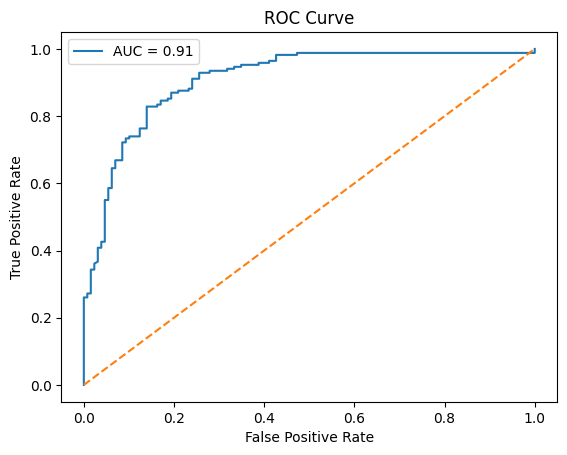

In [48]:
from sklearn.metrics import roc_curve, auc

y_prob = classifier_regressor.predict_proba(X_test_processed)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

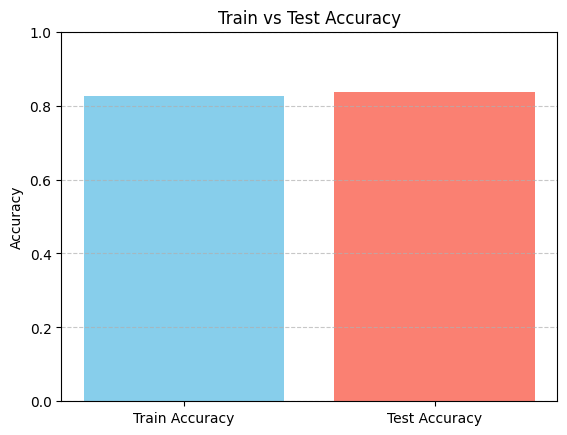

In [49]:
train_acc = accuracy_score(y_train, classifier_regressor.predict(X_train_processed))
test_acc = accuracy_score(y_test, classifier_regressor.predict(X_test_processed))

# Plot
plt.bar(['Train Accuracy', 'Test Accuracy'], [train_acc, test_acc], color=['skyblue', 'salmon'])
plt.ylim(0, 1)
plt.title('Train vs Test Accuracy')
plt.ylabel('Accuracy')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Confusion Matrix

In [50]:
from sklearn.metrics import confusion_matrix
import pandas as pd
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm,
                     index=["Actual 0", "Actual 1"],
                     columns=["Predicted 0", "Predicted 1"])

print("Confusion Matrix:")
print(cm_df)


Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0          104           25
Actual 1           24          145


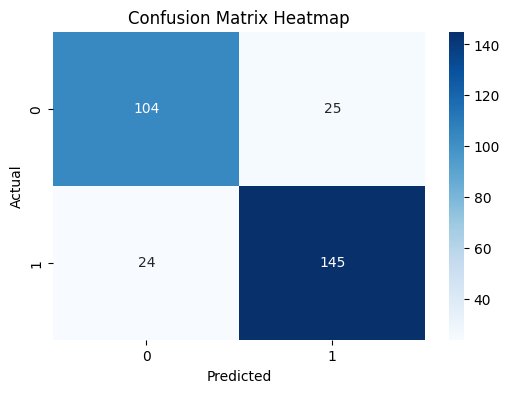

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

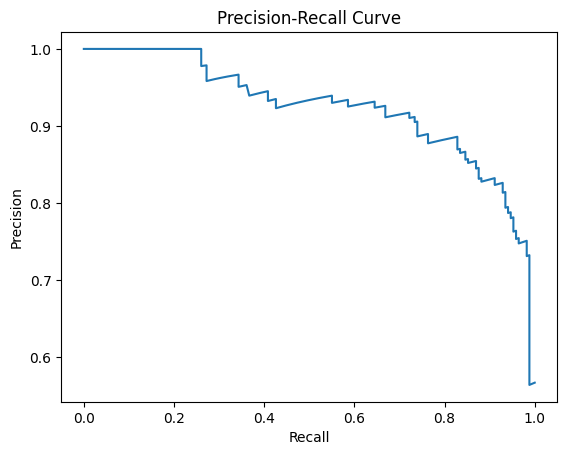

In [52]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

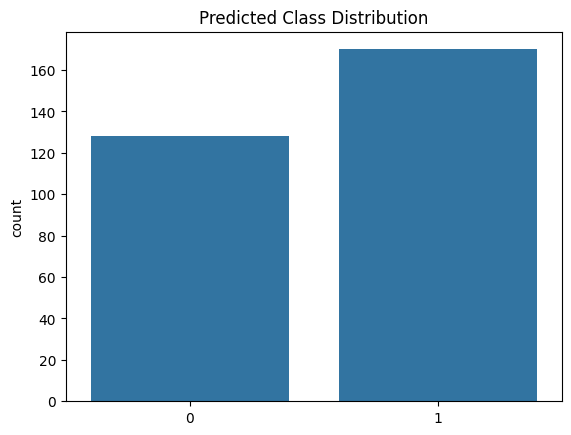

In [53]:
sns.countplot(x=y_pred)
plt.title("Predicted Class Distribution")
plt.show()

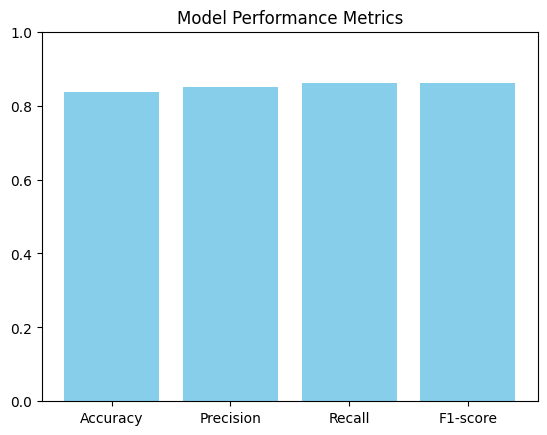

In [54]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
values = [
    accuracy_score(y_test, y_pred),
    0.85,  # replace with actual precision
    0.86,  # replace with recall
    0.86   # replace with f1
]

plt.bar(metrics, values, color='skyblue')
plt.title("Model Performance Metrics")
plt.ylim(0,1)
plt.show()

Cross-validation score

In [55]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    classifier_regressor.best_estimator_,
    X_train_processed,
    y_train,
    cv=5
)

print("CV Scores:", cv_scores)
print("Mean CV Score:", cv_scores.mean())

CV Scores: [0.87150838 0.84357542 0.8258427  0.80337079 0.76966292]
Mean CV Score: 0.8227920406754128


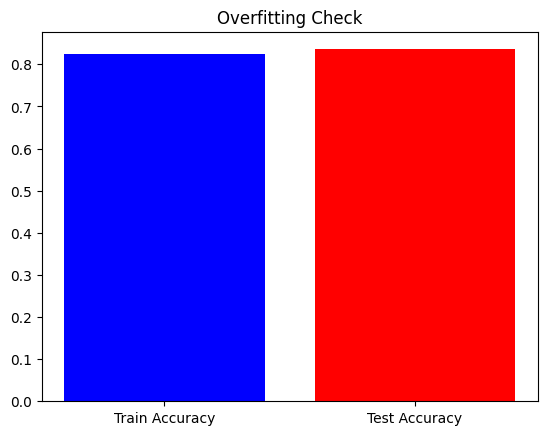

In [56]:
plt.bar(['Train Accuracy', 'Test Accuracy'], [train_acc, test_acc], color=['blue','red'])
plt.title("Overfitting Check")
plt.show()

## 2. NAIVE BAYES

Model

In [57]:
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()

In [58]:
# No need to apply GridSearchCV here as Naive Bayes does not have a lot of parameters to tune.
# Do NOT use classifier.best_params_ and classifier.best_score_ over here as they come from GridSearchCV
nb_model.fit(X_train, y_train)

GaussianNB()

Prediction + accuracy

In [59]:
y_pred = nb_model.predict(X_test)
score = accuracy_score(y_test, y_pred)
print(score)
print(classification_report(y_test, y_pred))

0.8288590604026845
              precision    recall  f1-score   support

           0       0.81      0.79      0.80       129
           1       0.84      0.86      0.85       169

    accuracy                           0.83       298
   macro avg       0.83      0.82      0.83       298
weighted avg       0.83      0.83      0.83       298



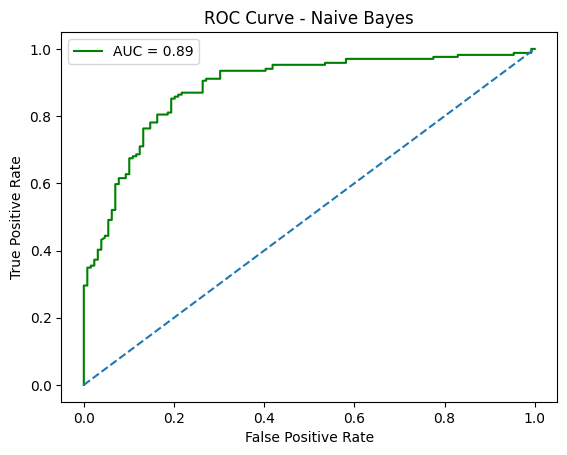

In [60]:
from sklearn.metrics import roc_curve, auc

y_prob = nb_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}", color='green')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Naive Bayes")
plt.legend()

plt.show()

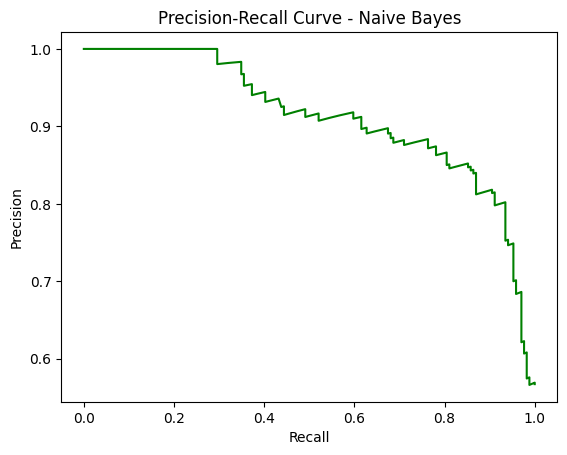

In [61]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision, color='green')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Naive Bayes")

plt.show()

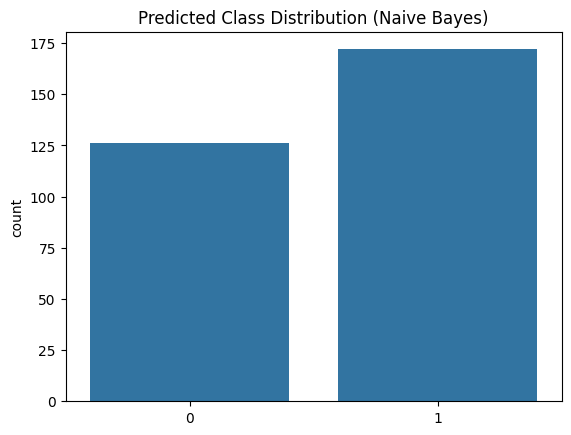

In [62]:
sns.countplot(x=y_pred)
plt.title("Predicted Class Distribution (Naive Bayes)")
plt.show()

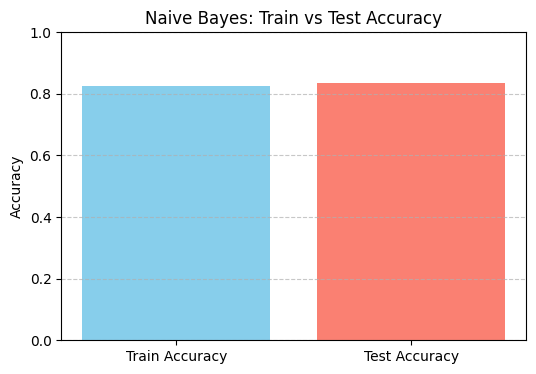

In [63]:
plt.figure(figsize=(6,4))

plt.bar(['Train Accuracy', 'Test Accuracy'], [train_acc, test_acc],
        color=['skyblue', 'salmon'])

plt.ylim(0, 1)
plt.title('Naive Bayes: Train vs Test Accuracy')
plt.ylabel('Accuracy')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

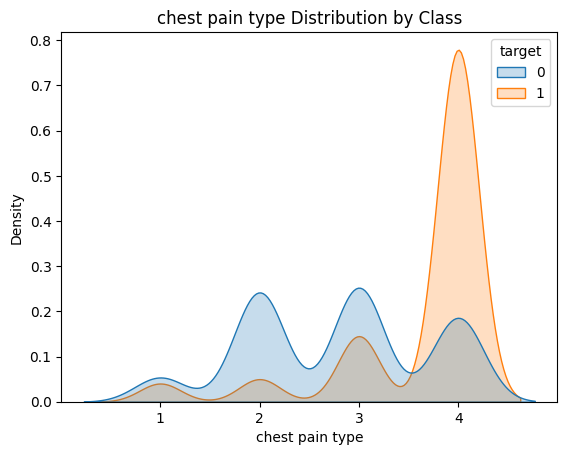

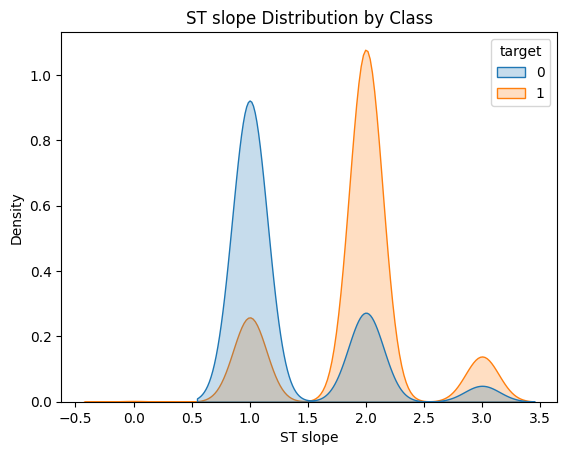

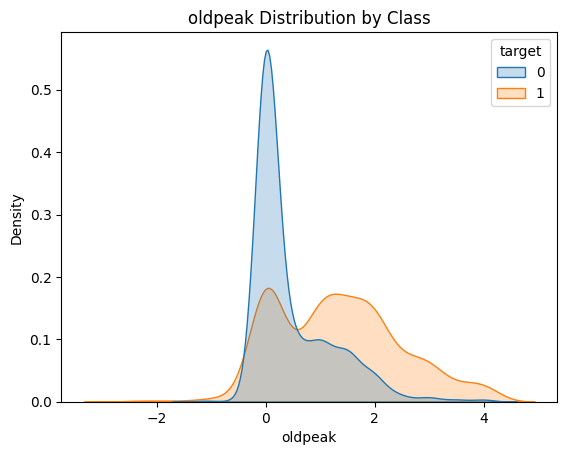

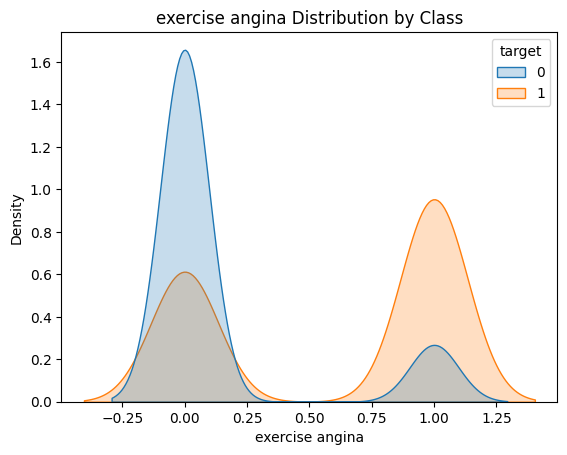

In [64]:
for col in X.columns[:4]:  # first few features
    sns.kdeplot(data=df, x=col, hue='target', fill=True)
    plt.title(f"{col} Distribution by Class")
    plt.show()

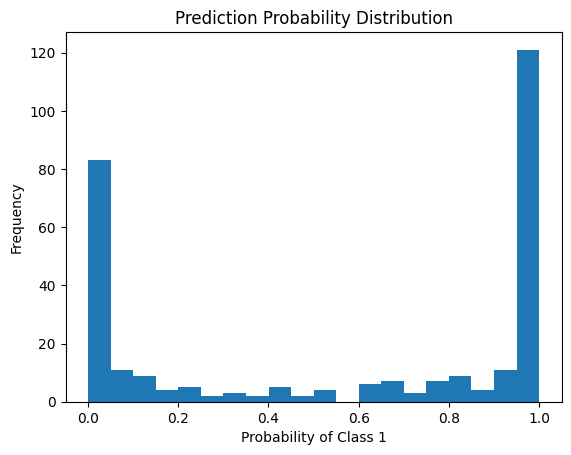

In [65]:
plt.hist(y_prob, bins=20)
plt.title("Prediction Probability Distribution")
plt.xlabel("Probability of Class 1")
plt.ylabel("Frequency")
plt.show()

Confusion Matrix

In [66]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Convert to DataFrame for better readability
cm_df = pd.DataFrame(cm,
                     index=["Actual 0", "Actual 1"],
                     columns=["Predicted 0", "Predicted 1"])

print("Confusion Matrix:")
print(cm_df)

Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0          102           27
Actual 1           24          145


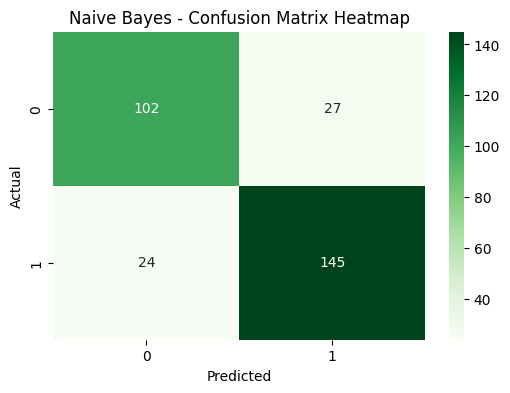

In [67]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

plt.title("Naive Bayes - Confusion Matrix Heatmap")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#### In Naive Bayes using scaled data to perform prediction cause a sudden drop in the accuracy from 0.82 to almost 0.64. This might have been because GaussianNB assumes each numerical feature follows a Gaussian (normal) distribution. When you scaled your features with StandardScaler, you changed their distribution (mean = 0, variance = 1). If your raw features already matched Gaussian-like behavior, scaling might have hurt instead of helped.

* So with Naive Bayes we have not used scaled data

## 3. K NEAREST NEIGHBOR

Model

In [68]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier()

In [69]:
from sklearn.model_selection import GridSearchCV
parameter = {'n_neighbors': [3, 5, 7, 8, 9, 10, 11, 12, 15, 20, 24], 'weights': ['uniform', 'distance'], 'metric': ['euclidean', 'manhattan']}

Here the parameters mean as follows
1. n_neighbors: Number of neighbors to be considered for calculating the minimum distance
2. 'weights': Is the weight of all the distance found UNIFORMLY impacting the model.

  OR

  Are they on the basis of DISTANCE such that closer the neighbor (small value of distance) more the weight
3. metric: Which method is used to calculate the distance [euclidean or manhattan]

In [70]:
classifier_neighbor = GridSearchCV(classifier, param_grid = parameter, scoring = 'accuracy', cv = 5)

In [71]:
classifier_neighbor.fit(X_train_processed, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5, 7, 8, 9, 10, 11, 12, 15, 20, 24],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

Prediction + Accuracy

In [72]:

print(classifier_neighbor.best_params_)
print(classifier_neighbor.best_score_)

{'metric': 'euclidean', 'n_neighbors': 24, 'weights': 'distance'}
0.8867051660284979


In [73]:
y_pred = classifier_neighbor.predict(X_test_processed)

In [74]:
from sklearn.metrics import accuracy_score, classification_report
score = accuracy_score(y_test, y_pred)
print(score)
print(classification_report(y_test, y_pred))

0.9026845637583892
              precision    recall  f1-score   support

           0       0.88      0.89      0.89       129
           1       0.92      0.91      0.91       169

    accuracy                           0.90       298
   macro avg       0.90      0.90      0.90       298
weighted avg       0.90      0.90      0.90       298



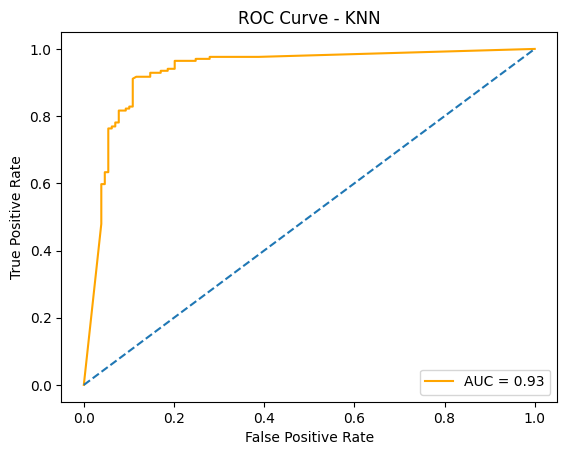

In [75]:
from sklearn.metrics import roc_curve, auc

y_prob = classifier_neighbor.predict_proba(X_test_processed)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}", color='orange')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN")
plt.legend()

plt.show()

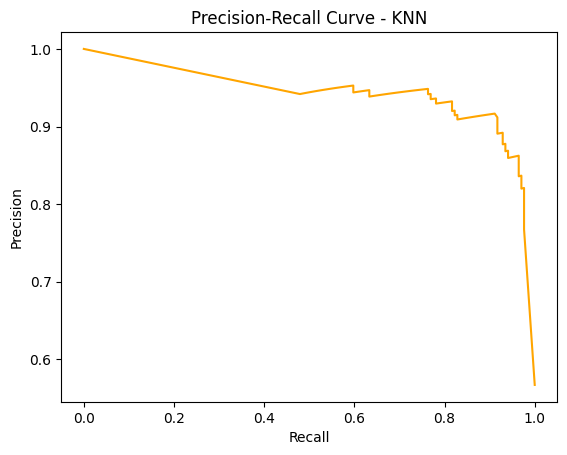

In [76]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision, color='orange')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - KNN")

plt.show()

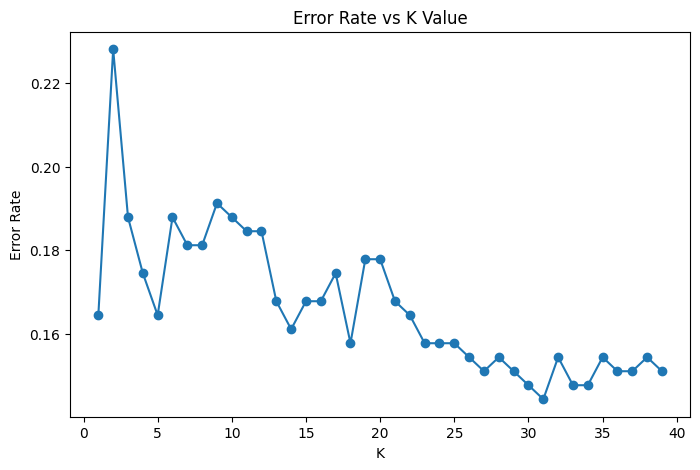

In [77]:
error_rate = []

for k in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_processed, y_train)
    pred_k = knn.predict(X_test_processed)
    error_rate.append(np.mean(pred_k != y_test))

plt.figure(figsize=(8,5))
plt.plot(range(1,40), error_rate, marker='o')

plt.title("Error Rate vs K Value")
plt.xlabel("K")
plt.ylabel("Error Rate")

plt.show()

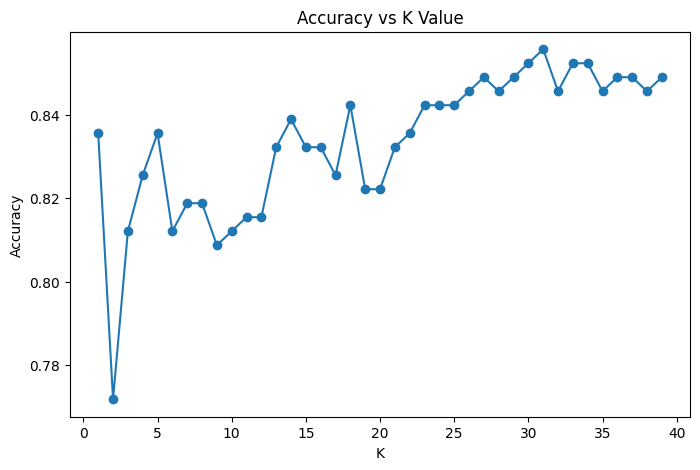

In [78]:
acc = []

for k in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_processed, y_train)
    acc.append(accuracy_score(y_test, knn.predict(X_test_processed)))

plt.figure(figsize=(8,5))
plt.plot(range(1,40), acc, marker='o')

plt.title("Accuracy vs K Value")
plt.xlabel("K")
plt.ylabel("Accuracy")

plt.show()

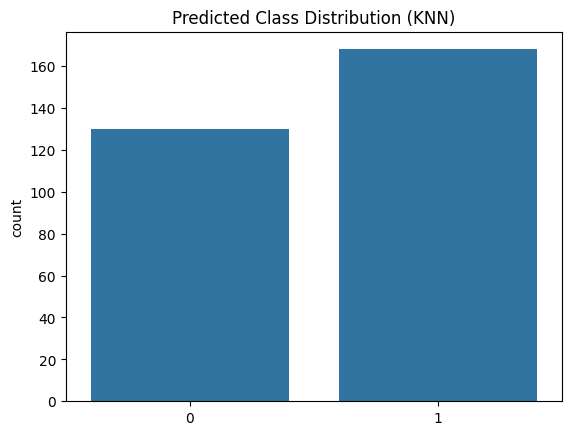

In [79]:
sns.countplot(x=y_pred)
plt.title("Predicted Class Distribution (KNN)")
plt.show()

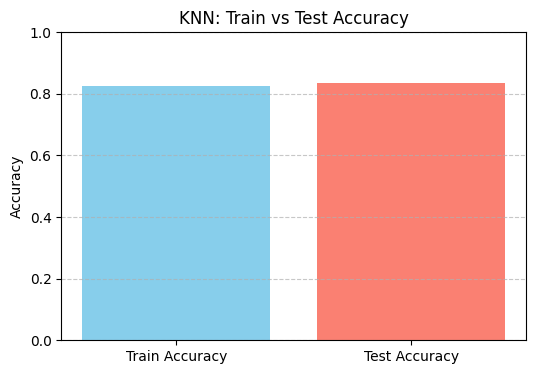

In [80]:
plt.figure(figsize=(6,4))

plt.bar(['Train Accuracy', 'Test Accuracy'],
        [train_acc, test_acc],
        color=['skyblue', 'salmon'])

plt.ylim(0,1)
plt.title('KNN: Train vs Test Accuracy')
plt.ylabel('Accuracy')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

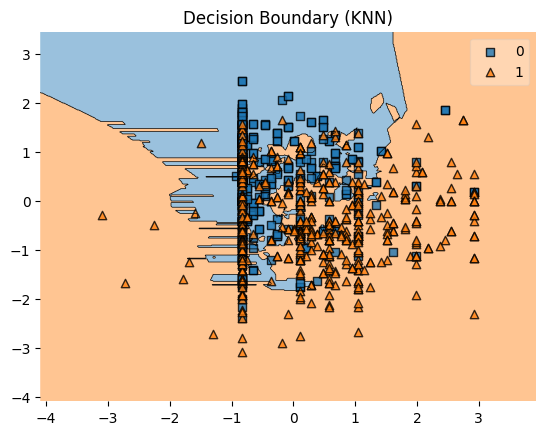

In [81]:
from mlxtend.plotting import plot_decision_regions

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_processed[:, :2], y_train)

plot_decision_regions(X_train_processed[:, :2], y_train.values, clf=knn)
plt.title("Decision Boundary (KNN)")
plt.show()

Confusion Matrix

In [82]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Convert to DataFrame for better readability
cm_df = pd.DataFrame(cm,
                     index=["Actual 0", "Actual 1"],
                     columns=["Predicted 0", "Predicted 1"])

print("Confusion Matrix:")
print(cm_df)

Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0          115           14
Actual 1           15          154


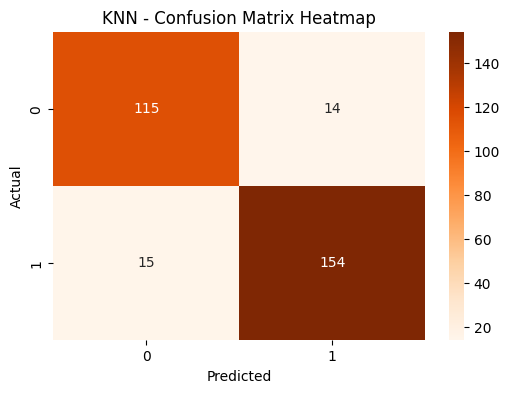

In [83]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')

plt.title("KNN - Confusion Matrix Heatmap")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 4. SUPPORT VECTOR MACHINE

Model

In [84]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Define classifier
classifier = SVC(probability=True)   # probability=True allows predict_proba later

# Optimized parameter grid
parameter = {
    'C': [0.1, 1, 5, 10],            # enough to cover underfitting → well-regularized
    'kernel': ['linear', 'rbf'],     # poly is rarely beneficial for this dataset
    'gamma': ['scale', 'auto']       # handles feature scaling adaptively
}

# GridSearchCV with parallel processing
classifier_SVM = GridSearchCV(
    estimator=classifier,
    param_grid=parameter,
    scoring='accuracy',
    cv=5,             # 5-fold CV for reliable evaluation
    n_jobs=-1,        # use all CPU cores
    verbose=2         # print progress so you know it’s running
)

# Fit model
classifier_SVM.fit(X_train_processed, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5, estimator=SVC(probability=True), n_jobs=-1,
             param_grid={'C': [0.1, 1, 5, 10], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf']},
             scoring='accuracy', verbose=2)

In [85]:
print(classifier_SVM.best_params_)
print(classifier_SVM.best_score_)

{'C': 5, 'gamma': 'scale', 'kernel': 'rbf'}
0.8418366706421443


Prediction + Accuracy

In [86]:
y_pred = classifier_SVM.predict(X_test_processed)

In [87]:
from sklearn.metrics import accuracy_score, classification_report
score = accuracy_score(y_test, y_pred)
print(score)
print(classification_report(y_test, y_pred))

0.8288590604026845
              precision    recall  f1-score   support

           0       0.81      0.79      0.80       129
           1       0.84      0.86      0.85       169

    accuracy                           0.83       298
   macro avg       0.83      0.82      0.83       298
weighted avg       0.83      0.83      0.83       298



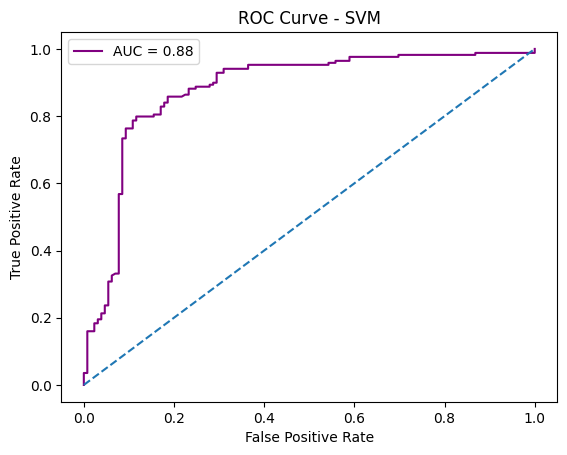

In [88]:
from sklearn.metrics import roc_curve, auc

y_prob = classifier_SVM.predict_proba(X_test_processed)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}", color='purple')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()

plt.show()

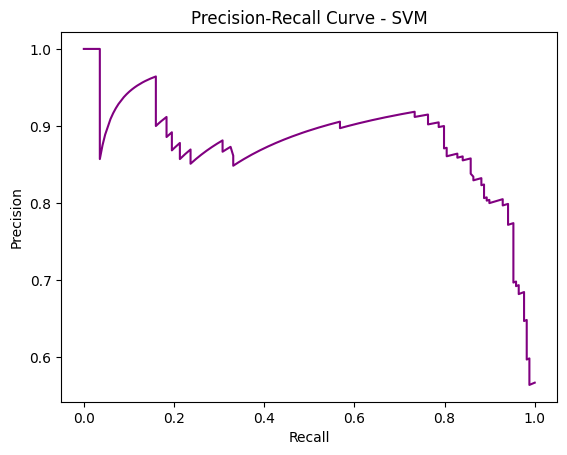

In [89]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision, color='purple')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - SVM")

plt.show()

In [90]:
plt.figure(figsize=(6,4))

plt.plot(cv_scores_svm_baseline, marker='o', linestyle='--')

plt.title("SVM Cross-Validation Scores")
plt.xlabel("Fold")
plt.ylabel("Accuracy")

plt.show()

NameError: name 'cv_scores_svm_baseline' is not defined

<Figure size 600x400 with 0 Axes>

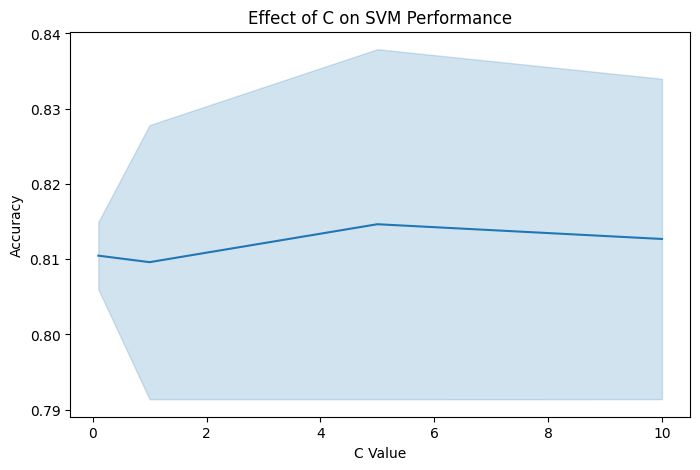

In [91]:
results = pd.DataFrame(classifier_SVM.cv_results_)

plt.figure(figsize=(8,5))
sns.lineplot(x='param_C', y='mean_test_score', data=results)

plt.title("Effect of C on SVM Performance")
plt.xlabel("C Value")
plt.ylabel("Accuracy")

plt.show()

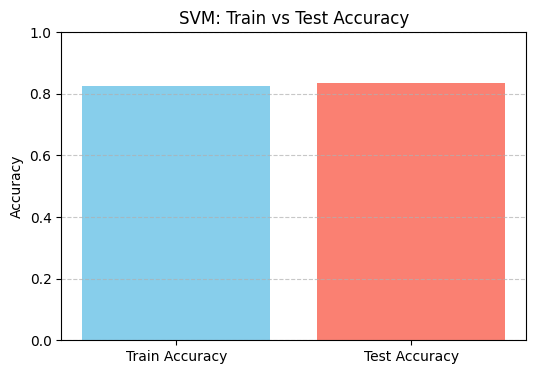

In [92]:
plt.figure(figsize=(6,4))

plt.bar(['Train Accuracy', 'Test Accuracy'],
        [train_acc, test_acc],
        color=['skyblue', 'salmon'])

plt.ylim(0,1)
plt.title('SVM: Train vs Test Accuracy')
plt.ylabel('Accuracy')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Confusion matrix

In [93]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Convert to DataFrame for better readability
cm_df = pd.DataFrame(cm,
                     index=["Actual 0", "Actual 1"],
                     columns=["Predicted 0", "Predicted 1"])

print("Confusion Matrix:")
print(cm_df)

Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0          102           27
Actual 1           24          145


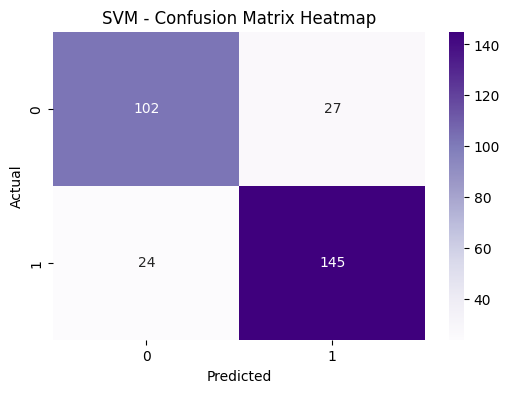

In [94]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')

plt.title("SVM - Confusion Matrix Heatmap")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


In [95]:
# Existing code
from sklearn.model_selection import cross_val_score
cv_scores_svm_baseline = cross_val_score(classifier_SVM, X_train_processed, y_train, cv=5, scoring='accuracy')
print(f"Baseline SVM Cross-Validation Accuracy: {cv_scores_svm_baseline.mean():.2%}")
# Make sure cv_scores_svm_baseline is now defined
print(f"Individual fold scores (Baseline SVM): {cv_scores_svm_baseline}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Baseline SVM Cross-Validation Accuracy: 83.40%
Individual fold scores (Baseline SVM): [0.87709497 0.88268156 0.82022472 0.79775281 0.79213483]


In [96]:
svm_model = classifier_SVM.best_estimator_

print("Number of Support Vectors:", svm_model.n_support_)

Number of Support Vectors: [177 198]


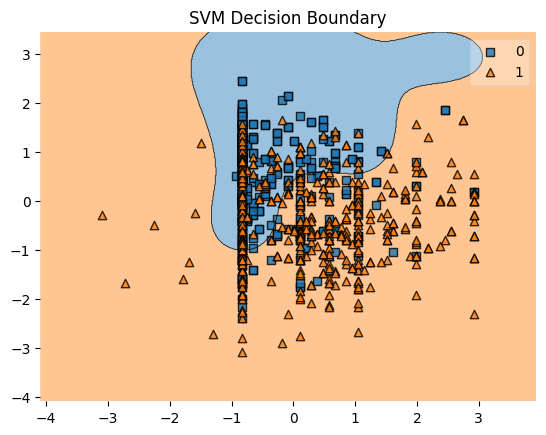

In [97]:
from mlxtend.plotting import plot_decision_regions

svm_model.fit(X_train_processed[:, :2], y_train)

plot_decision_regions(X_train_processed[:, :2], y_train.values, clf=svm_model)
plt.title("SVM Decision Boundary")
plt.show()

## 5. DECISION TREE

Model


In [98]:
from sklearn.tree import DecisionTreeClassifier
treemodel = DecisionTreeClassifier()

In [99]:
parameter2 = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'splitter': ['best', 'random'],
    'max_depth': [3,4,5,6,7],
    'max_features': [None, 'sqrt', 'log2']
}

In [106]:
from sklearn.model_selection import GridSearchCV
cv = GridSearchCV(treemodel, param_grid = parameter2, cv = 5, scoring = 'accuracy')

In [107]:
cv.fit(X_train_processed, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [3, 4, 5, 6, 7],
                         'max_features': [None, 'sqrt', 'log2'],
                         'splitter': ['best', 'random']},
             scoring='accuracy')

In [108]:
print(cv.best_params_)

{'criterion': 'entropy', 'max_depth': 7, 'max_features': 'sqrt', 'splitter': 'best'}


Predictions + Accuracy

In [109]:
y_pred = cv.predict(X_test_processed)

In [110]:
score = accuracy_score(y_test, y_pred)
print(score)
print(classification_report(y_test, y_pred))

0.8187919463087249
              precision    recall  f1-score   support

           0       0.79      0.79      0.79       129
           1       0.84      0.84      0.84       169

    accuracy                           0.82       298
   macro avg       0.82      0.82      0.82       298
weighted avg       0.82      0.82      0.82       298



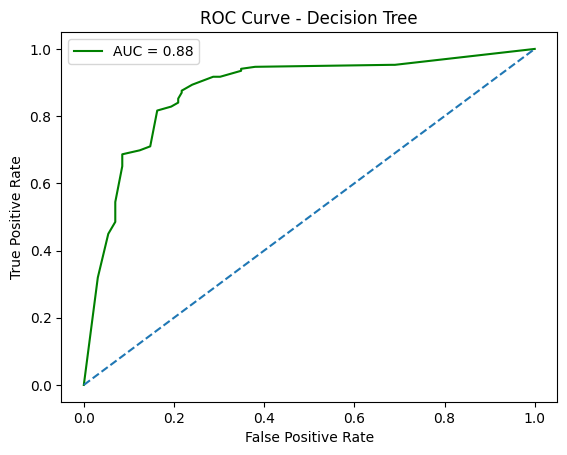

In [111]:
from sklearn.metrics import roc_curve, auc

y_prob = cv.predict_proba(X_test_processed)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}", color='green')
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()

plt.show()

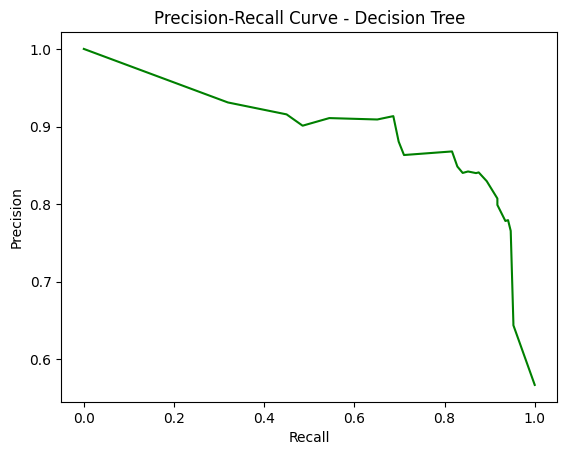

In [112]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision, color='green')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Decision Tree")

plt.show()

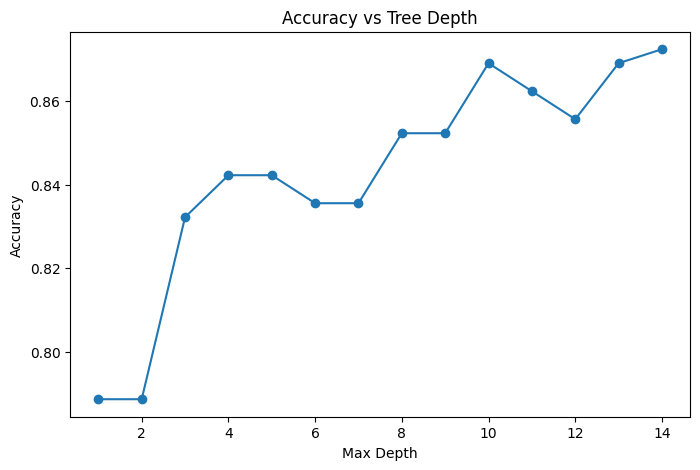

In [113]:
depths = range(1,15)
acc = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d)
    model.fit(X_train_processed, y_train)
    acc.append(accuracy_score(y_test, model.predict(X_test_processed)))

plt.figure(figsize=(8,5))
plt.plot(depths, acc, marker='o')

plt.title("Accuracy vs Tree Depth")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")

plt.show()

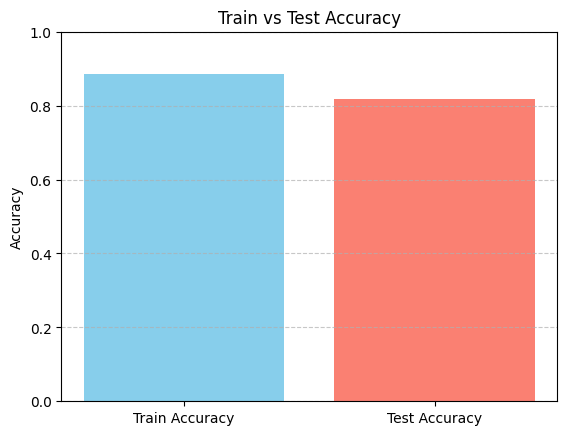

In [114]:
train_acc = accuracy_score(y_train, cv.predict(X_train_processed))
test_acc = accuracy_score(y_test, cv.predict(X_test_processed))

# Plot
plt.bar(['Train Accuracy', 'Test Accuracy'], [train_acc, test_acc], color=['skyblue', 'salmon'])
plt.ylim(0, 1)
plt.title('Train vs Test Accuracy')
plt.ylabel('Accuracy')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

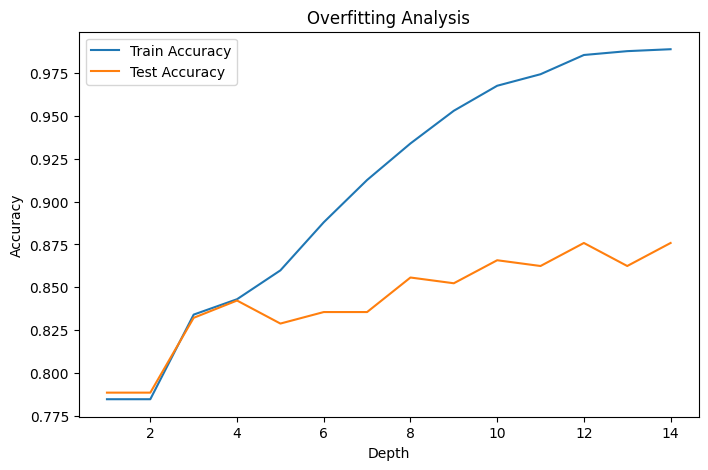

In [115]:
train_acc_list = []
test_acc_list = []

for d in range(1,15):
    model = DecisionTreeClassifier(max_depth=d)
    model.fit(X_train_processed, y_train)

    train_acc_list.append(accuracy_score(y_train, model.predict(X_train_processed)))
    test_acc_list.append(accuracy_score(y_test, model.predict(X_test_processed)))

plt.figure(figsize=(8,5))
plt.plot(range(1,15), train_acc_list, label='Train Accuracy')
plt.plot(range(1,15), test_acc_list, label='Test Accuracy')

plt.legend()
plt.xlabel("Depth")
plt.ylabel("Accuracy")
plt.title("Overfitting Analysis")

plt.show()

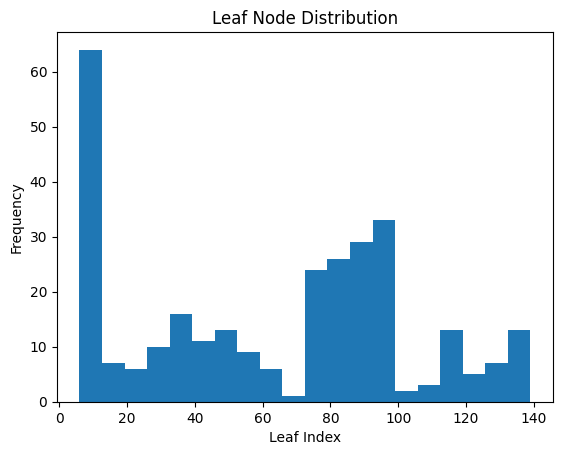

In [116]:
leaf_nodes = cv.best_estimator_.apply(X_test_processed)

plt.hist(leaf_nodes, bins=20)
plt.title("Leaf Node Distribution")
plt.xlabel("Leaf Index")
plt.ylabel("Frequency")
plt.show()

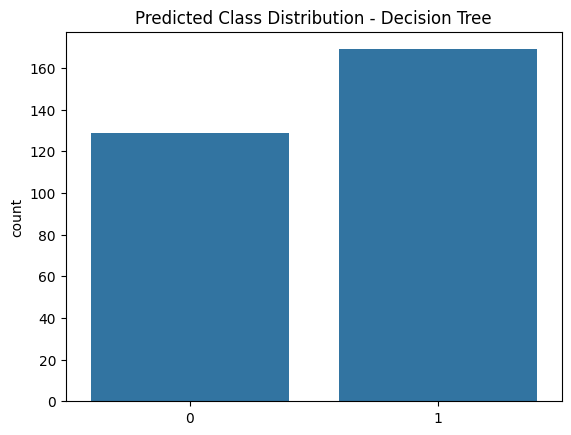

In [117]:
sns.countplot(x=y_pred)
plt.title("Predicted Class Distribution - Decision Tree")
plt.show()

Confusion matrix

In [118]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Convert to DataFrame for better readability
cm_df = pd.DataFrame(cm,
                     index=["Actual 0", "Actual 1"],
                     columns=["Predicted 0", "Predicted 1"])

print("Confusion Matrix:")
print(cm_df)

Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0          102           27
Actual 1           27          142


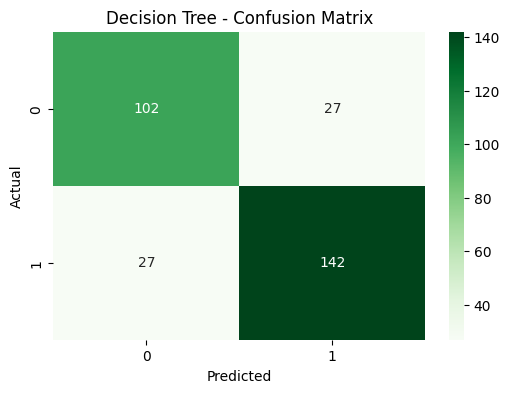

In [119]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Earlier we tried using post prunning via hyperparameter tuning.

Now we shall also try by using pre prunning methods

In [120]:
from sklearn.tree import DecisionTreeClassifier
treemodel = DecisionTreeClassifier(max_depth = 5)

In [121]:
treemodel.fit(X_train_processed, y_train)

DecisionTreeClassifier(max_depth=5)

[Text(0.5384615384615384, 0.9166666666666666, 'x[7] <= 0.5\ngini = 0.5\nsamples = 892\nvalue = [432.0, 460.0]'),
 Text(0.3076923076923077, 0.75, 'x[5] <= 0.5\ngini = 0.349\nsamples = 488\nvalue = [110, 378]'),
 Text(0.4230769230769231, 0.8333333333333333, 'True  '),
 Text(0.15384615384615385, 0.5833333333333334, 'x[1] <= -0.152\ngini = 0.498\nsamples = 154\nvalue = [72, 82]'),
 Text(0.07692307692307693, 0.4166666666666667, 'x[10] <= 0.5\ngini = 0.352\nsamples = 57\nvalue = [13, 44]'),
 Text(0.038461538461538464, 0.25, 'x[0] <= 0.247\ngini = 0.477\nsamples = 28\nvalue = [11, 17]'),
 Text(0.019230769230769232, 0.08333333333333333, 'gini = 0.5\nsamples = 18\nvalue = [9, 9]'),
 Text(0.057692307692307696, 0.08333333333333333, 'gini = 0.32\nsamples = 10\nvalue = [2, 8]'),
 Text(0.11538461538461539, 0.25, 'x[1] <= -1.621\ngini = 0.128\nsamples = 29\nvalue = [2, 27]'),
 Text(0.09615384615384616, 0.08333333333333333, 'gini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.1346153846153846, 0.08333

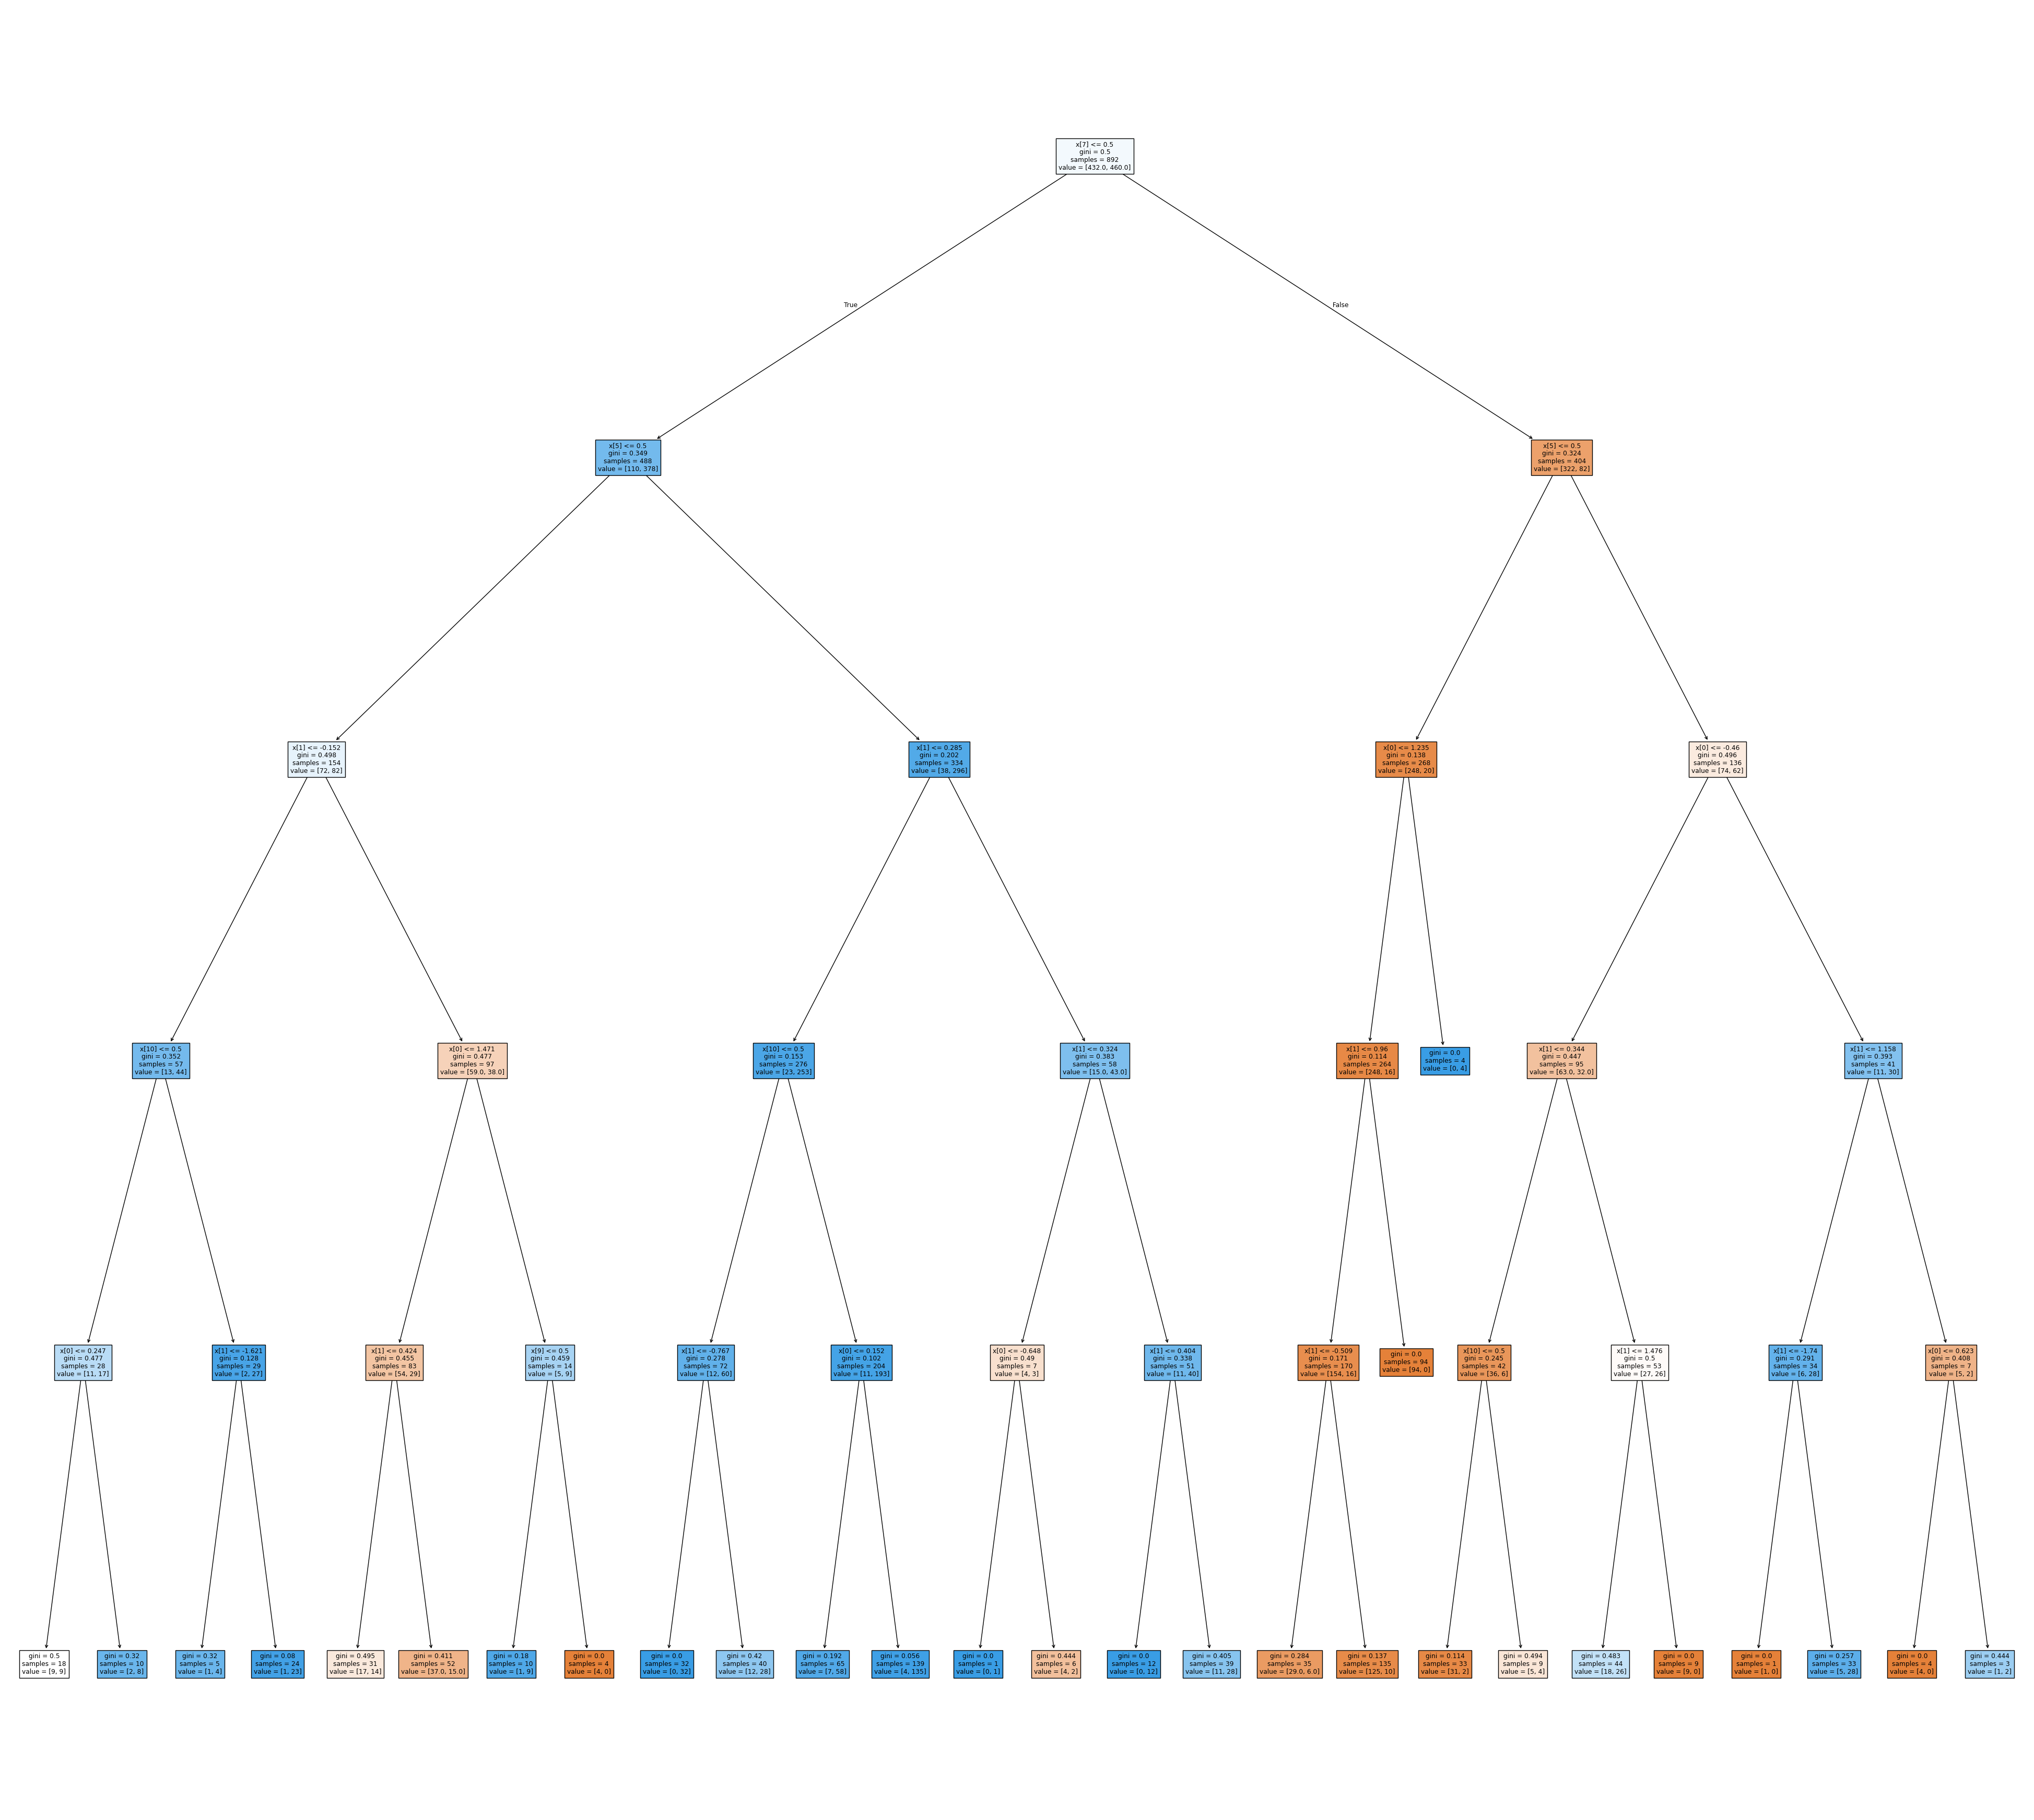

In [122]:
from sklearn import tree
plt.figure(figsize = (50, 45))
tree.plot_tree(treemodel, filled = True) # Boxes of the tree come filled with some colour

In [123]:
y_pred = treemodel.predict(X_test_processed)

In [124]:
from sklearn.metrics import accuracy_score, classification_report
score = accuracy_score(y_test, y_pred)
print(score)
print(classification_report(y_test, y_pred))

0.8288590604026845
              precision    recall  f1-score   support

           0       0.79      0.82      0.81       129
           1       0.86      0.83      0.85       169

    accuracy                           0.83       298
   macro avg       0.83      0.83      0.83       298
weighted avg       0.83      0.83      0.83       298



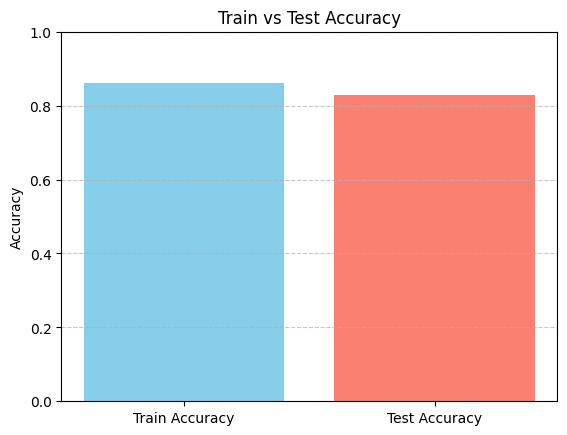

In [125]:
train_acc = accuracy_score(y_train, treemodel.predict(X_train_processed))
test_acc = accuracy_score(y_test, treemodel.predict(X_test_processed))

# Plot
plt.bar(['Train Accuracy', 'Test Accuracy'], [train_acc, test_acc], color=['skyblue', 'salmon'])
plt.ylim(0, 1)
plt.title('Train vs Test Accuracy')
plt.ylabel('Accuracy')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Confusion matrix

In [126]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Convert to DataFrame for better readability
cm_df = pd.DataFrame(cm,
                     index=["Actual 0", "Actual 1"],
                     columns=["Predicted 0", "Predicted 1"])

print("Confusion Matrix:")
print(cm_df)

Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0          106           23
Actual 1           28          141


______________________________________________
## Trying with depth 4 instead of 5 after the new scaler method

In [127]:
from sklearn.tree import DecisionTreeClassifier
treemodel = DecisionTreeClassifier(max_depth = 4)

In [128]:
treemodel.fit(X_train_processed, y_train)

DecisionTreeClassifier(max_depth=4)

[Text(0.5267857142857143, 0.9, 'x[7] <= 0.5\ngini = 0.5\nsamples = 892\nvalue = [432.0, 460.0]'),
 Text(0.2857142857142857, 0.7, 'x[5] <= 0.5\ngini = 0.349\nsamples = 488\nvalue = [110, 378]'),
 Text(0.40625, 0.8, 'True  '),
 Text(0.14285714285714285, 0.5, 'x[1] <= -0.152\ngini = 0.498\nsamples = 154\nvalue = [72, 82]'),
 Text(0.07142857142857142, 0.3, 'x[10] <= 0.5\ngini = 0.352\nsamples = 57\nvalue = [13, 44]'),
 Text(0.03571428571428571, 0.1, 'gini = 0.477\nsamples = 28\nvalue = [11, 17]'),
 Text(0.10714285714285714, 0.1, 'gini = 0.128\nsamples = 29\nvalue = [2, 27]'),
 Text(0.21428571428571427, 0.3, 'x[0] <= 1.471\ngini = 0.477\nsamples = 97\nvalue = [59.0, 38.0]'),
 Text(0.17857142857142858, 0.1, 'gini = 0.455\nsamples = 83\nvalue = [54, 29]'),
 Text(0.25, 0.1, 'gini = 0.459\nsamples = 14\nvalue = [5, 9]'),
 Text(0.42857142857142855, 0.5, 'x[1] <= 0.285\ngini = 0.202\nsamples = 334\nvalue = [38, 296]'),
 Text(0.35714285714285715, 0.3, 'x[10] <= 0.5\ngini = 0.153\nsamples = 276\nva

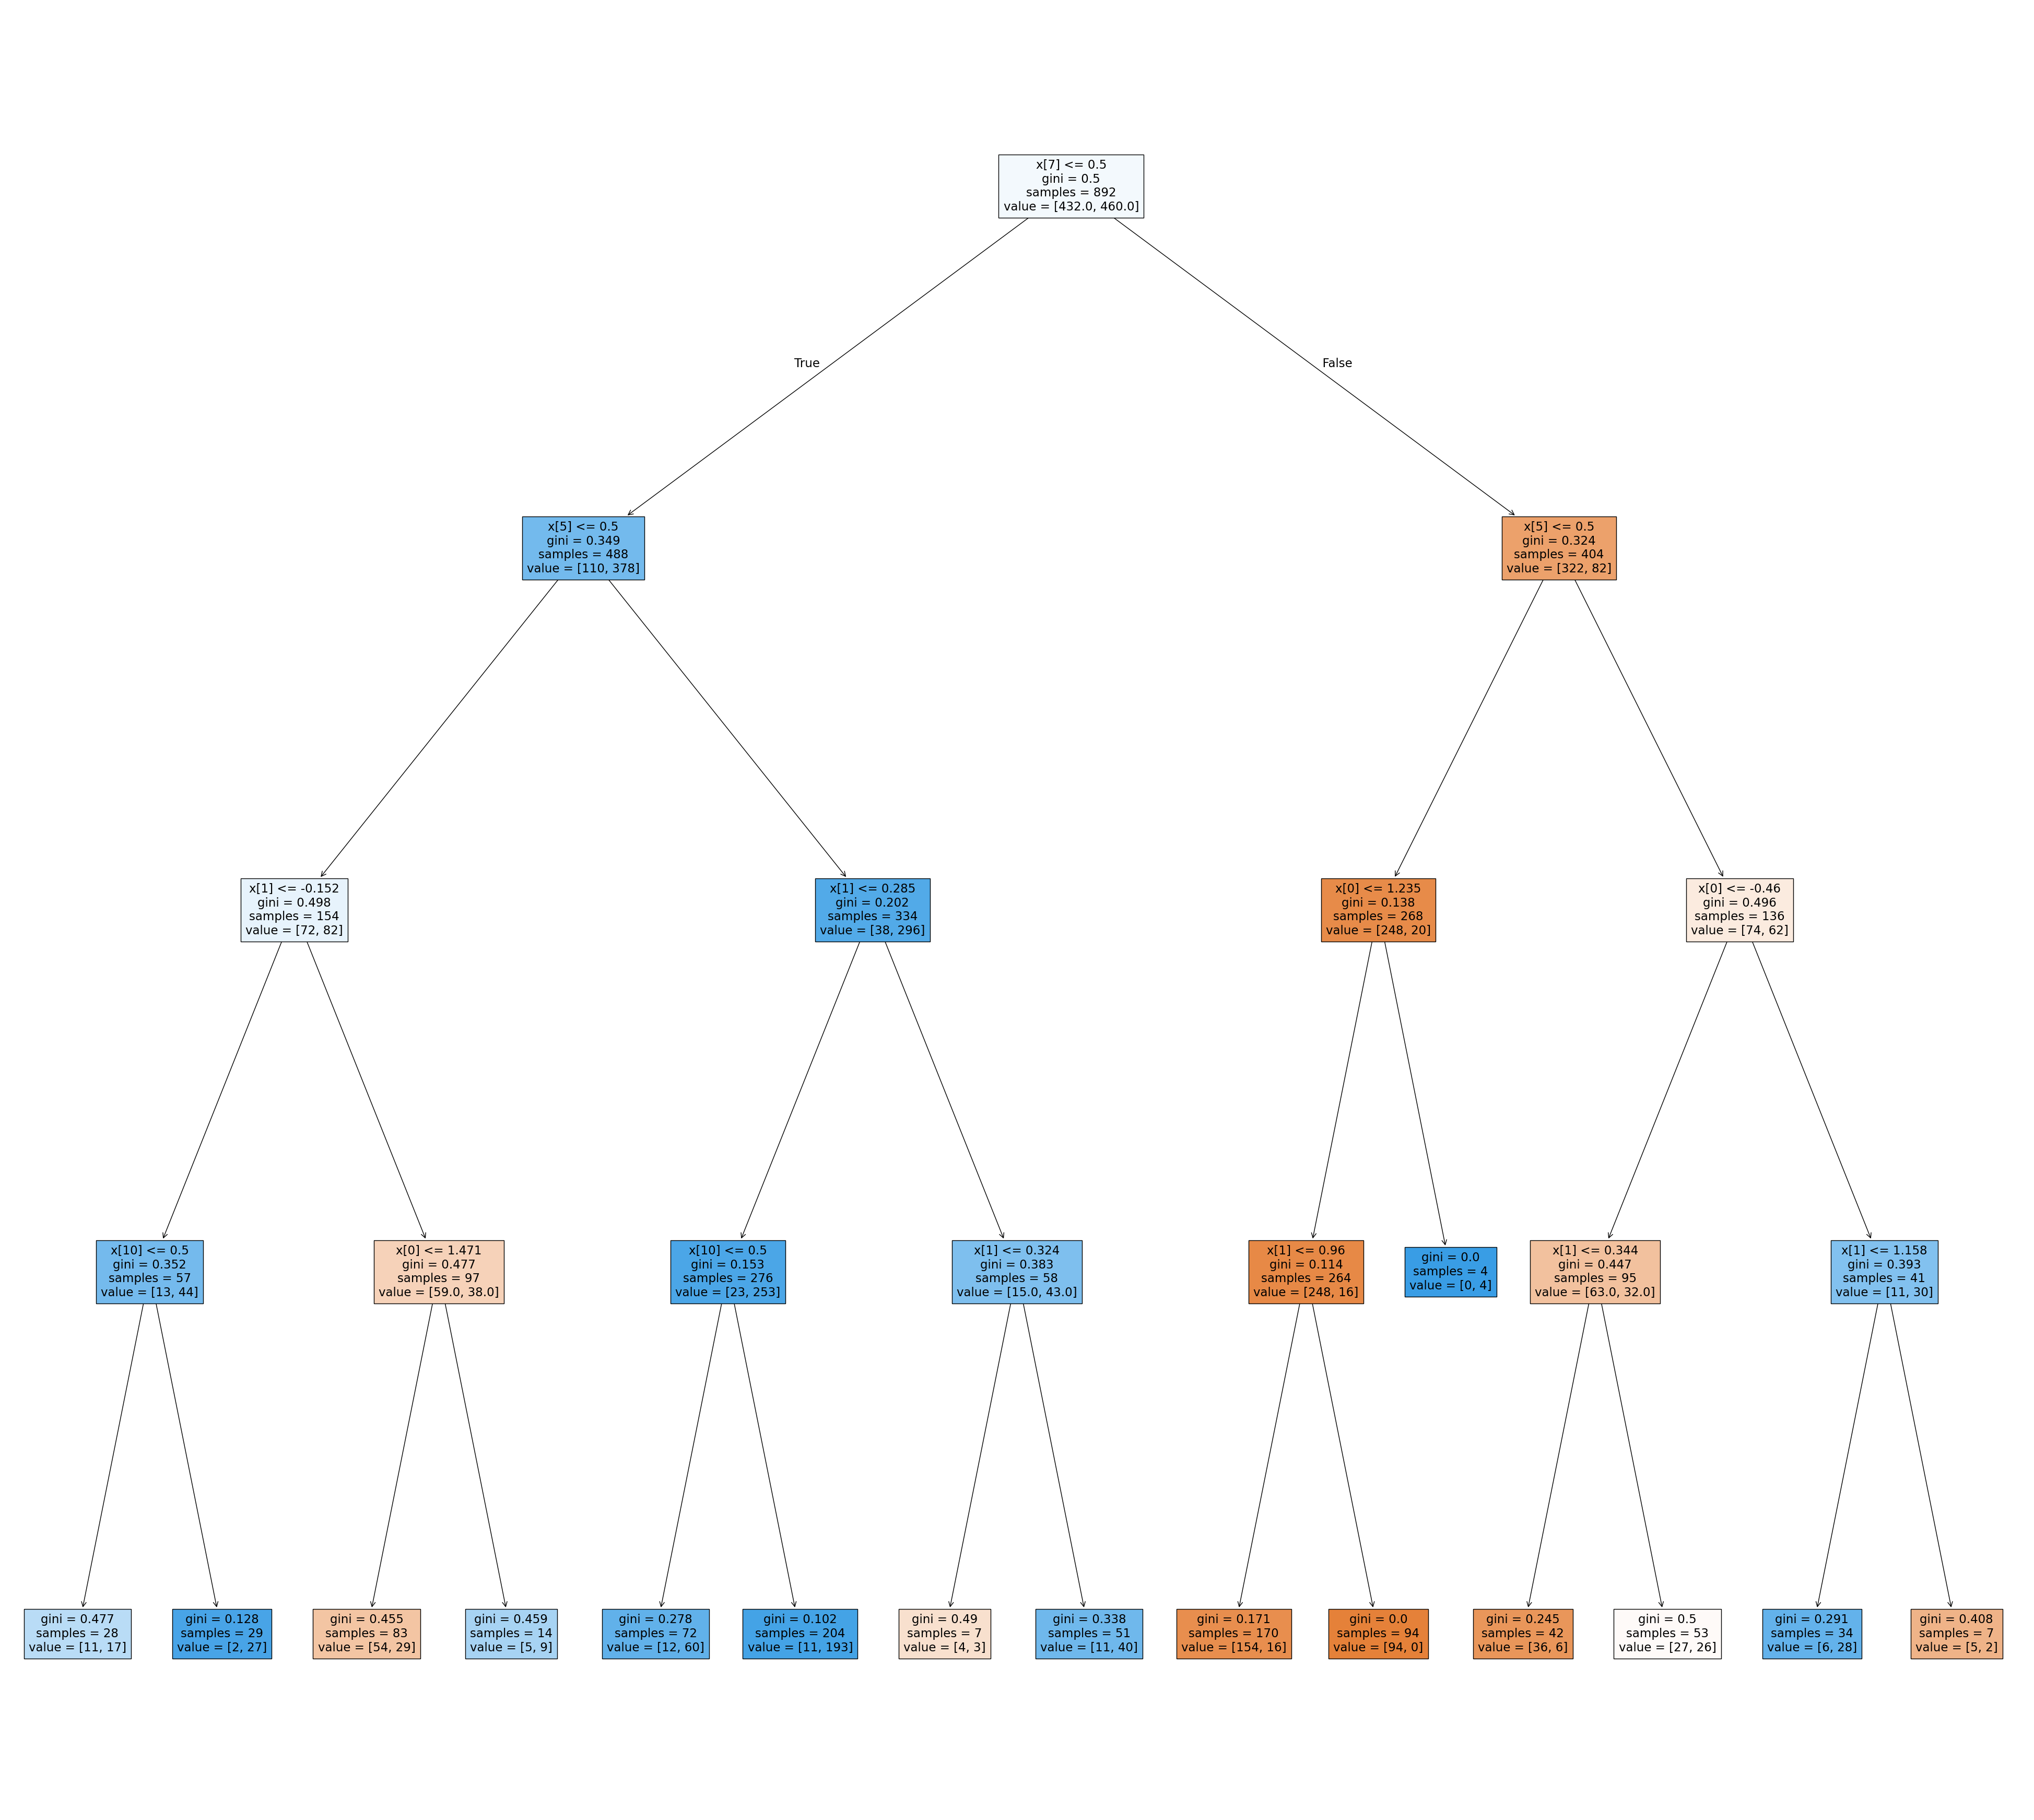

In [129]:
from sklearn import tree
plt.figure(figsize = (50, 45))
tree.plot_tree(treemodel, filled = True) # Boxes of the tree come filled with some colour

In [130]:
y_pred = treemodel.predict(X_test_processed)

In [131]:
from sklearn.metrics import accuracy_score, classification_report
score = accuracy_score(y_test, y_pred)
print(score)
print(classification_report(y_test, y_pred))

0.8422818791946308
              precision    recall  f1-score   support

           0       0.80      0.85      0.82       129
           1       0.88      0.83      0.86       169

    accuracy                           0.84       298
   macro avg       0.84      0.84      0.84       298
weighted avg       0.84      0.84      0.84       298



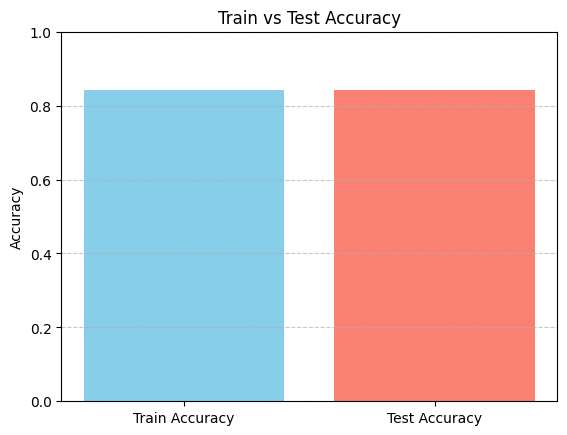

In [132]:
train_acc = accuracy_score(y_train, treemodel.predict(X_train_processed))
test_acc = accuracy_score(y_test, treemodel.predict(X_test_processed))

# Plot
plt.bar(['Train Accuracy', 'Test Accuracy'], [train_acc, test_acc], color=['skyblue', 'salmon'])
plt.ylim(0, 1)
plt.title('Train vs Test Accuracy')
plt.ylabel('Accuracy')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Confusion matrix

In [133]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Convert to DataFrame for better readability
cm_df = pd.DataFrame(cm,
                     index=["Actual 0", "Actual 1"],
                     columns=["Predicted 0", "Predicted 1"])

print("Confusion Matrix:")
print(cm_df)

Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0          110           19
Actual 1           28          141


___________________________________________
## Trying max depth = 3 as well since the new change

In [134]:
from sklearn.tree import DecisionTreeClassifier
treemodel = DecisionTreeClassifier(max_depth = 3)

In [135]:
treemodel.fit(X_train_processed, y_train)

DecisionTreeClassifier(max_depth=3)

[Text(0.5, 0.875, 'x[7] <= 0.5\ngini = 0.5\nsamples = 892\nvalue = [432.0, 460.0]'),
 Text(0.25, 0.625, 'x[5] <= 0.5\ngini = 0.349\nsamples = 488\nvalue = [110, 378]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[1] <= -0.152\ngini = 0.498\nsamples = 154\nvalue = [72, 82]'),
 Text(0.0625, 0.125, 'gini = 0.352\nsamples = 57\nvalue = [13, 44]'),
 Text(0.1875, 0.125, 'gini = 0.477\nsamples = 97\nvalue = [59.0, 38.0]'),
 Text(0.375, 0.375, 'x[1] <= 0.285\ngini = 0.202\nsamples = 334\nvalue = [38, 296]'),
 Text(0.3125, 0.125, 'gini = 0.153\nsamples = 276\nvalue = [23, 253]'),
 Text(0.4375, 0.125, 'gini = 0.383\nsamples = 58\nvalue = [15.0, 43.0]'),
 Text(0.75, 0.625, 'x[5] <= 0.5\ngini = 0.324\nsamples = 404\nvalue = [322, 82]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[0] <= 1.235\ngini = 0.138\nsamples = 268\nvalue = [248, 20]'),
 Text(0.5625, 0.125, 'gini = 0.114\nsamples = 264\nvalue = [248, 16]'),
 Text(0.6875, 0.125, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 T

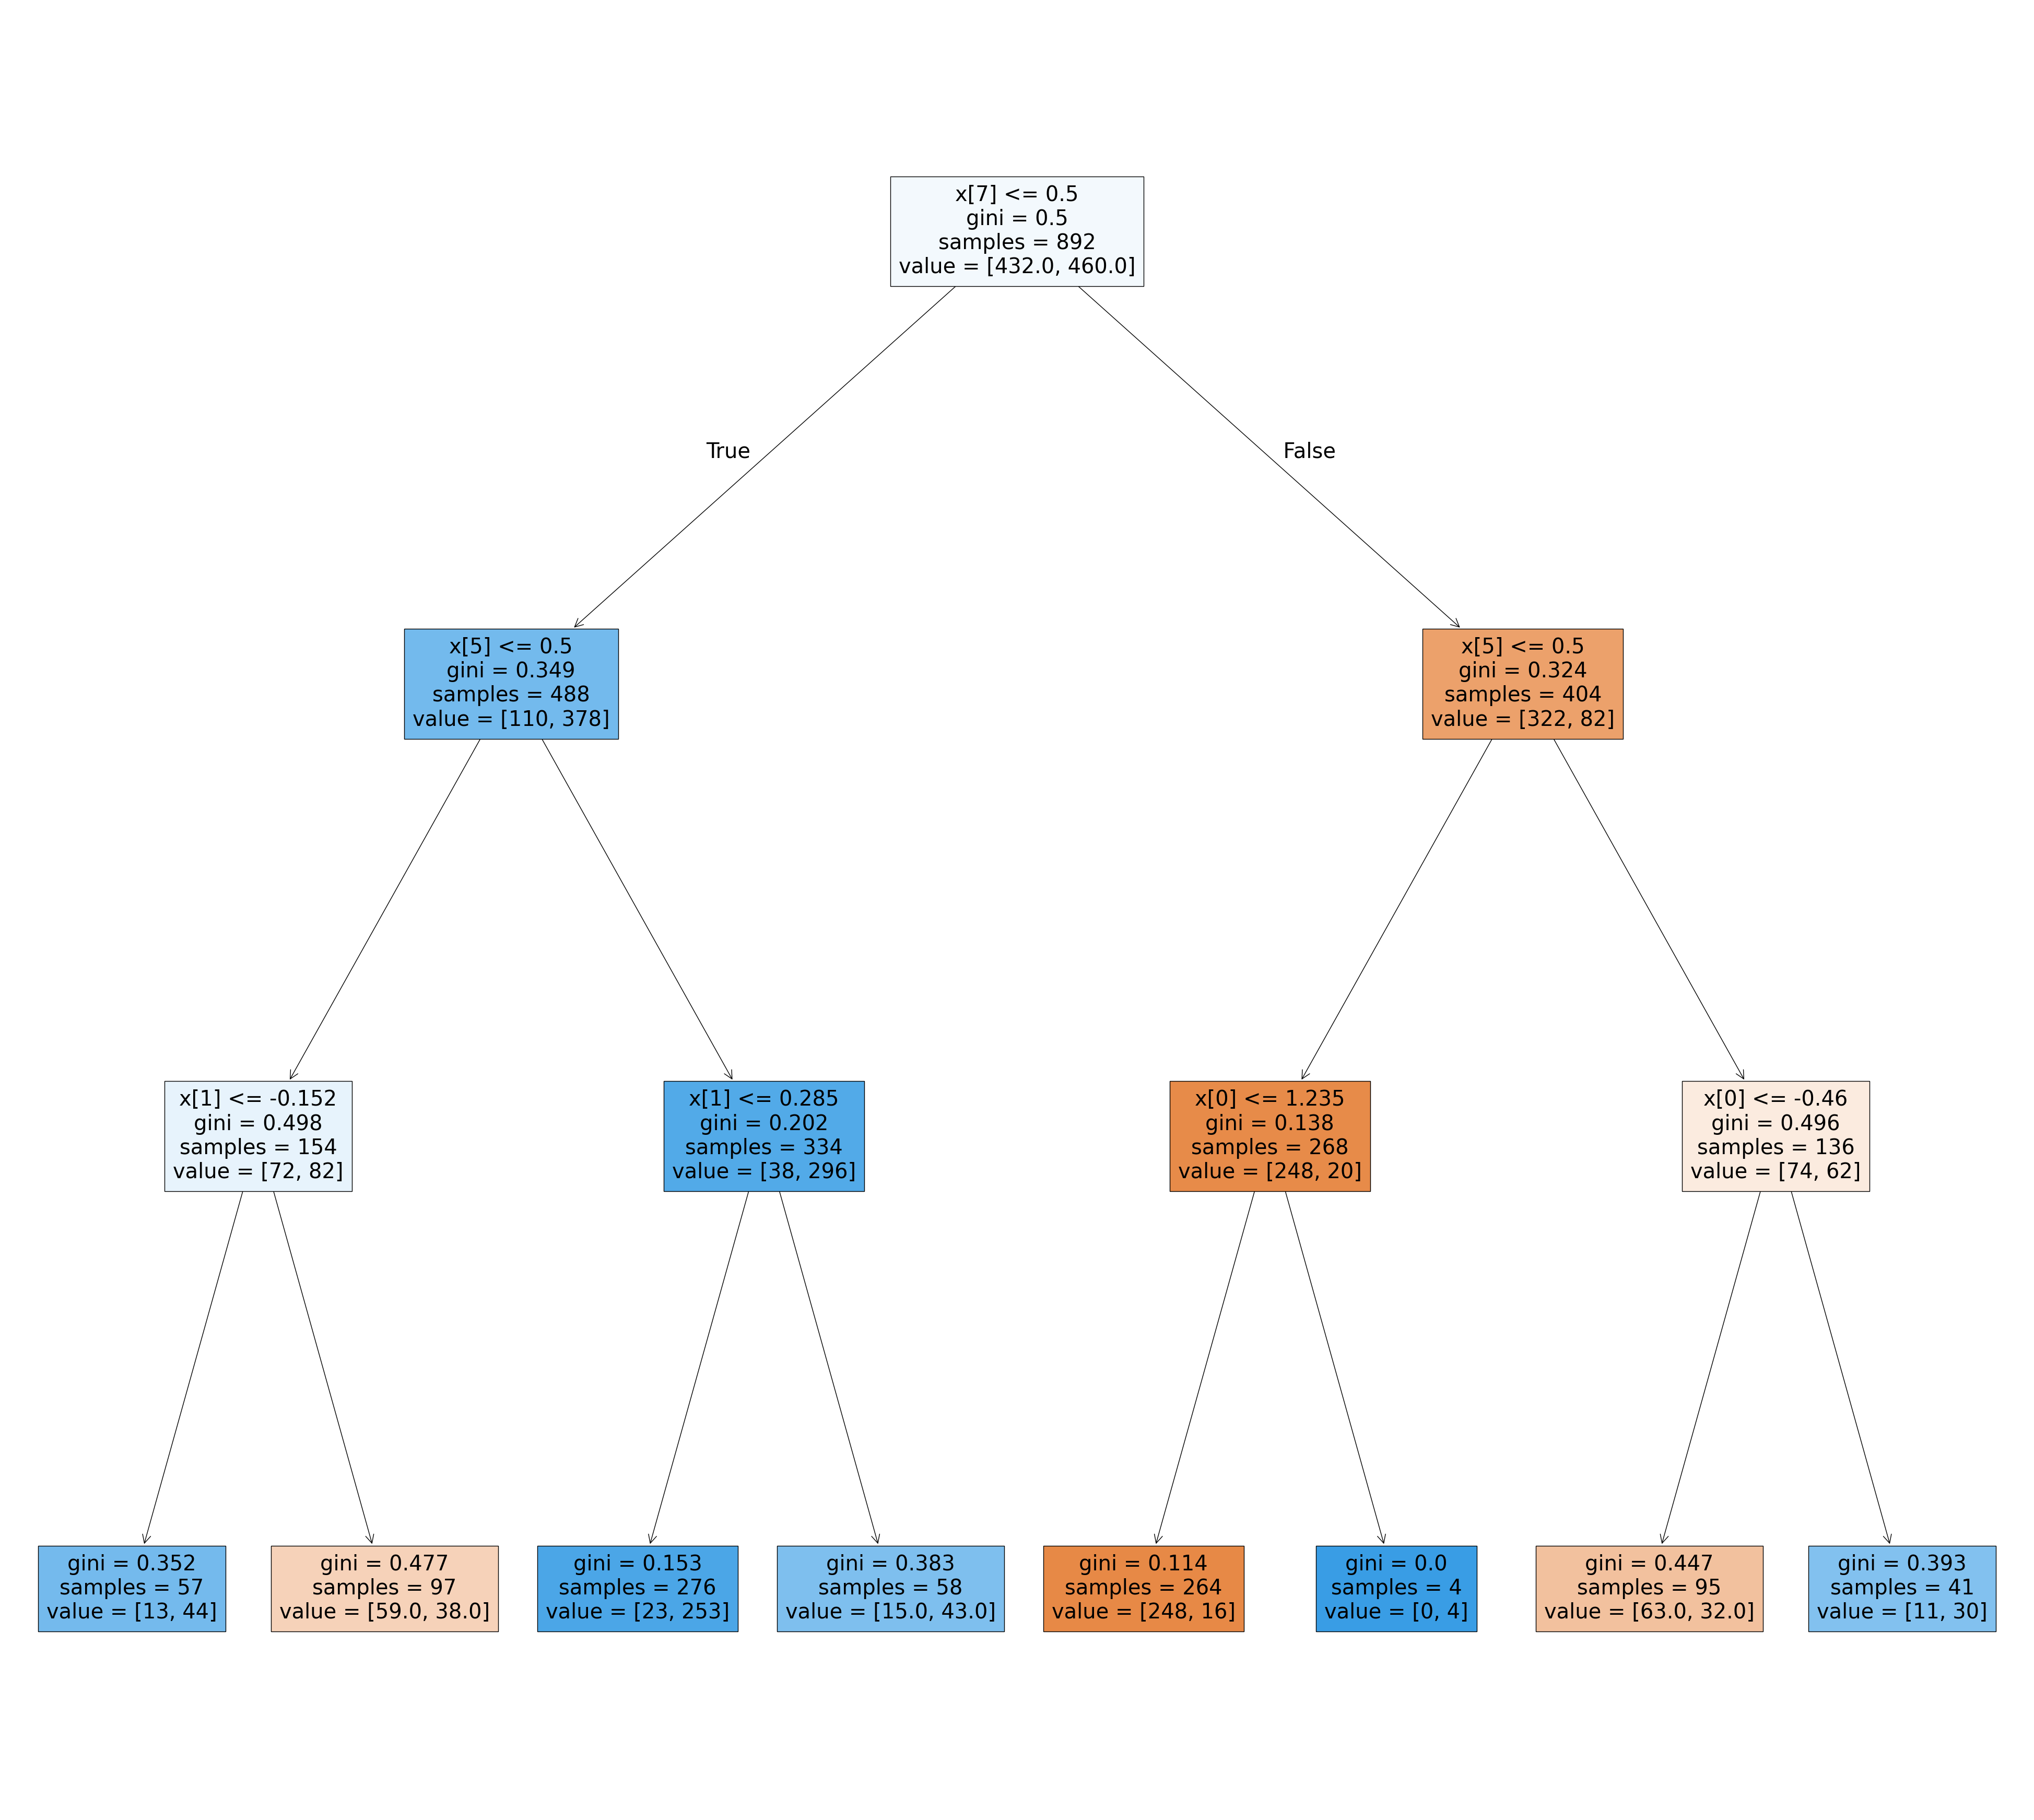

In [136]:
from sklearn import tree
plt.figure(figsize = (50, 45))
tree.plot_tree(treemodel, filled = True) # Boxes of the tree come filled with some colour

In [137]:
y_pred = treemodel.predict(X_test_processed)

In [138]:
from sklearn.metrics import accuracy_score, classification_report
score = accuracy_score(y_test, y_pred)
print(score)
print(classification_report(y_test, y_pred))

0.8322147651006712
              precision    recall  f1-score   support

           0       0.78      0.85      0.81       129
           1       0.88      0.82      0.85       169

    accuracy                           0.83       298
   macro avg       0.83      0.83      0.83       298
weighted avg       0.84      0.83      0.83       298



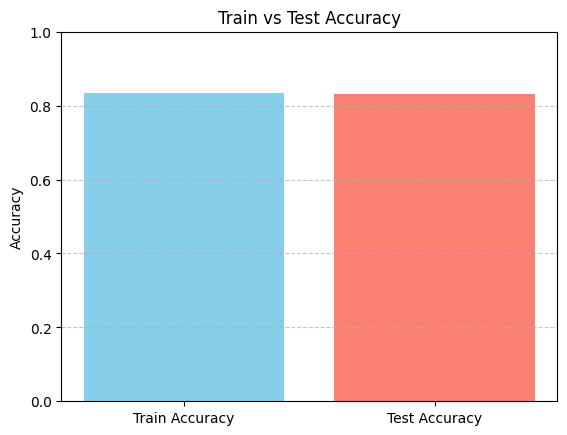

In [139]:
train_acc = accuracy_score(y_train, treemodel.predict(X_train_processed))
test_acc = accuracy_score(y_test, treemodel.predict(X_test_processed))

# Plot
plt.bar(['Train Accuracy', 'Test Accuracy'], [train_acc, test_acc], color=['skyblue', 'salmon'])
plt.ylim(0, 1)
plt.title('Train vs Test Accuracy')
plt.ylabel('Accuracy')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Confusion matrix

In [140]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Convert to DataFrame for better readability
cm_df = pd.DataFrame(cm,
                     index=["Actual 0", "Actual 1"],
                     columns=["Predicted 0", "Predicted 1"])

print("Confusion Matrix:")
print(cm_df)

Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0          110           19
Actual 1           31          138


The tree with max depth = 4 has the best accuracy out of all the trees

## 6. RANDOM FOREST

Model

In [141]:
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier()

In [142]:
parameter = {'n_estimators': [50, 100, 200], 'criterion': ['gini', 'entropy'], 'max_depth': [None, 5, 10], 'min_samples_split':[2,5], 'min_samples_leaf':[1,2]} # n_estimators refers to the number of trees in the forest

In [143]:
from sklearn.model_selection import GridSearchCV
classifier_random = GridSearchCV(classifier, param_grid = parameter, scoring = 'accuracy', cv = 5)

In [145]:
classifier_random.fit(X_train_processed, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 5, 10], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [146]:
print(classifier_random.best_params_)

{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


Prediction + Accuracy

In [147]:
y_pred = classifier_random.predict(X_test_processed)
score = accuracy_score(y_test, y_pred)
print(score)
print(classification_report(y_test, y_pred))

0.8657718120805369
              precision    recall  f1-score   support

           0       0.86      0.83      0.84       129
           1       0.87      0.89      0.88       169

    accuracy                           0.87       298
   macro avg       0.86      0.86      0.86       298
weighted avg       0.87      0.87      0.87       298



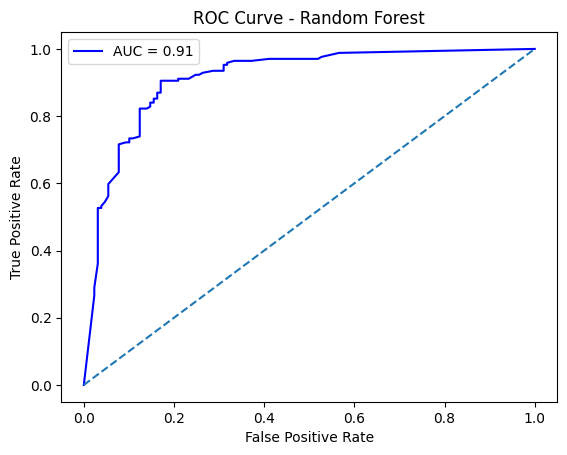

In [148]:
from sklearn.metrics import roc_curve, auc

y_prob = classifier_random.predict_proba(X_test_processed)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}", color='blue')
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.show()

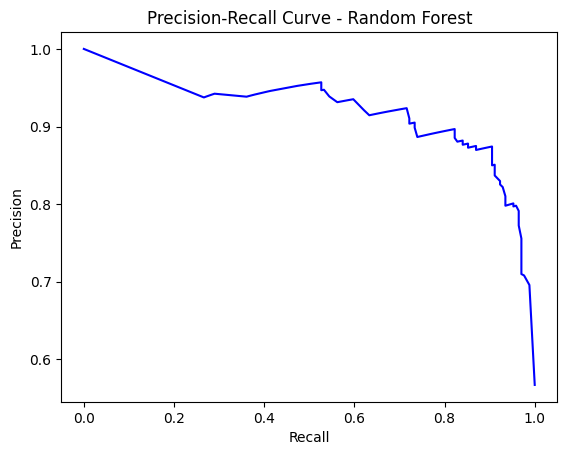

In [149]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision, color='blue')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Random Forest")

plt.show()

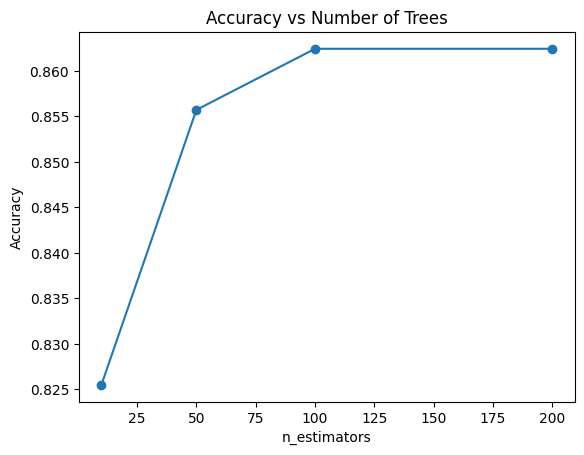

In [150]:
n_values = [10, 50, 100, 200]
acc = []

for n in n_values:
    model = RandomForestClassifier(n_estimators=n)
    model.fit(X_train_processed, y_train)
    acc.append(accuracy_score(y_test, model.predict(X_test_processed)))

plt.plot(n_values, acc, marker='o')
plt.title("Accuracy vs Number of Trees")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")

plt.show()

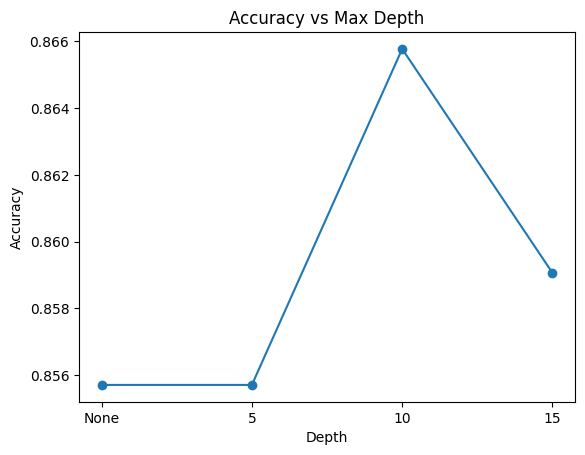

In [151]:
depths = [None, 5, 10, 15]
acc = []

for d in depths:
    model = RandomForestClassifier(max_depth=d)
    model.fit(X_train_processed, y_train)
    acc.append(accuracy_score(y_test, model.predict(X_test_processed)))

plt.plot([str(d) for d in depths], acc, marker='o')
plt.title("Accuracy vs Max Depth")
plt.xlabel("Depth")
plt.ylabel("Accuracy")

plt.show()

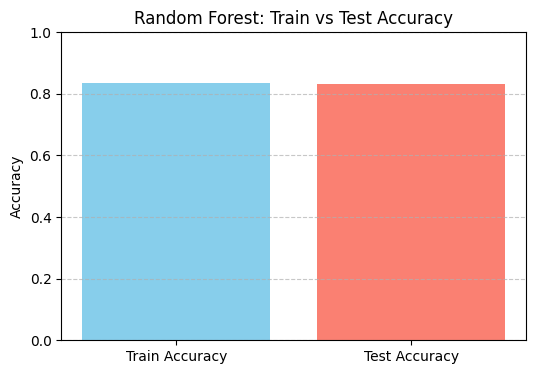

In [152]:
plt.figure(figsize=(6,4))

plt.bar(['Train Accuracy', 'Test Accuracy'],
        [train_acc, test_acc],
        color=['skyblue', 'salmon'])

plt.ylim(0,1)
plt.title('Random Forest: Train vs Test Accuracy')
plt.ylabel('Accuracy')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Confusion matrix

In [153]:
from sklearn.metrics import confusion_matrix
import pandas as pd
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Convert to DataFrame for better readability
cm_df = pd.DataFrame(cm,
index=["Actual 0", "Actual 1"],
columns=["Predicted 0", "Predicted 1"])
print("Confusion Matrix')")
print(cm_df)

Confusion Matrix')
          Predicted 0  Predicted 1
Actual 0          107           22
Actual 1           18          151


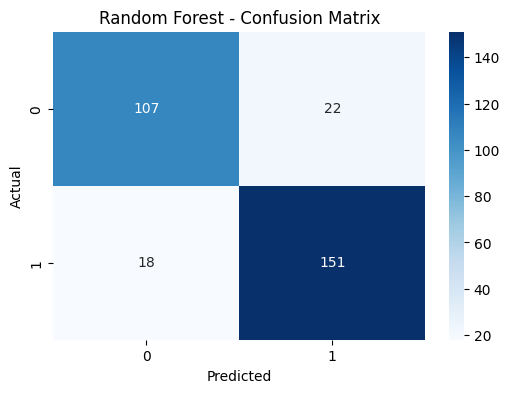

In [154]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [155]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.4 MB/s eta 0:00:00


In [156]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

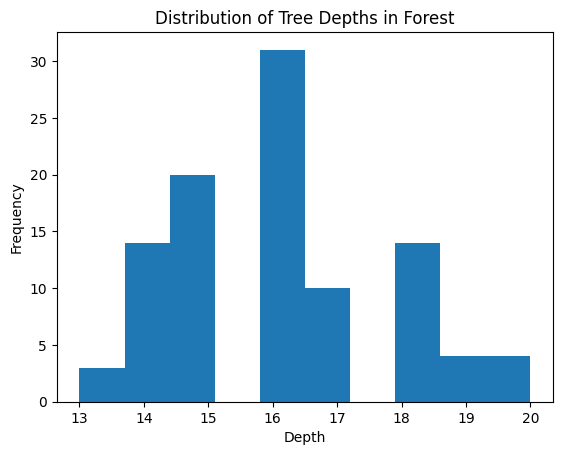

In [157]:
trees = classifier_random.best_estimator_.estimators_

depths = [tree.get_depth() for tree in trees]

plt.hist(depths, bins=10)
plt.title("Distribution of Tree Depths in Forest")
plt.xlabel("Depth")
plt.ylabel("Frequency")
plt.show()

## 7. XG BOOST

In [158]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1]
}

xgb_grid = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

xgb_grid.fit(X_train_processed, y_train)

best_xgb = xgb_grid.best_estimator_

y_pred = best_xgb.predict(X_test_processed)

print("Best XGB Params:", xgb_grid.best_params_)
score = accuracy_score(y_test, y_pred)
print(score)
print(classification_report(y_test, y_pred))

Best XGB Params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
0.87248322147651
              precision    recall  f1-score   support

           0       0.86      0.84      0.85       129
           1       0.88      0.89      0.89       169

    accuracy                           0.87       298
   macro avg       0.87      0.87      0.87       298
weighted avg       0.87      0.87      0.87       298



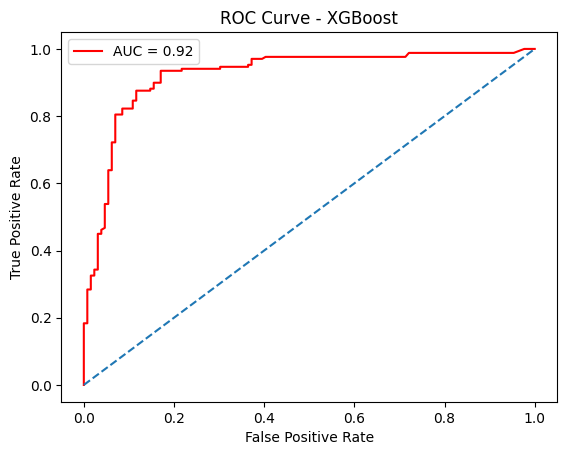

In [159]:
from sklearn.metrics import roc_curve, auc

y_prob = best_xgb.predict_proba(X_test_processed)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}", color='red')
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()

plt.show()

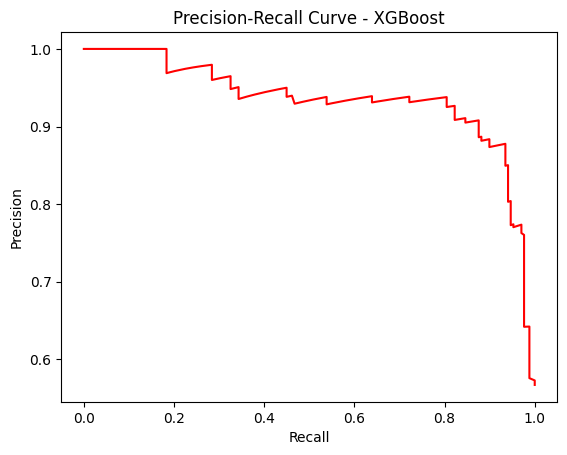

In [160]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision, color='red')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - XGBoost")

plt.show()

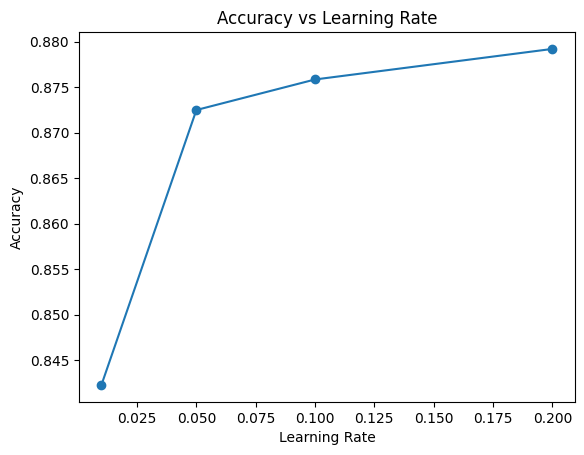

In [161]:
lr_values = [0.01, 0.05, 0.1, 0.2]
acc = []

for lr in lr_values:
    model = XGBClassifier(learning_rate=lr, eval_metric='logloss')
    model.fit(X_train_processed, y_train)
    acc.append(accuracy_score(y_test, model.predict(X_test_processed)))

plt.plot(lr_values, acc, marker='o')
plt.title("Accuracy vs Learning Rate")
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")

plt.show()

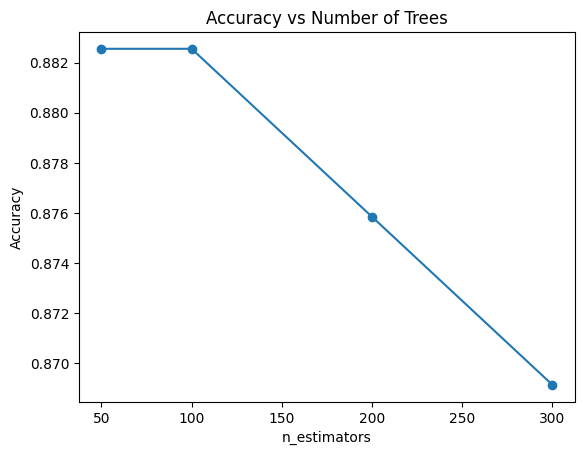

In [162]:
n_values = [50, 100, 200, 300]
acc = []

for n in n_values:
    model = XGBClassifier(n_estimators=n, eval_metric='logloss')
    model.fit(X_train_processed, y_train)
    acc.append(accuracy_score(y_test, model.predict(X_test_processed)))

plt.plot(n_values, acc, marker='o')
plt.title("Accuracy vs Number of Trees")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")

plt.show()

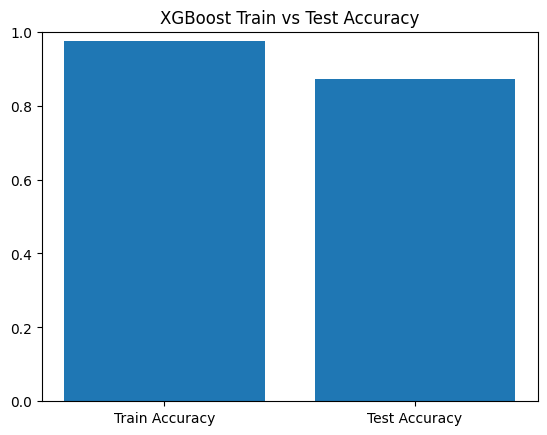

In [163]:
train_acc = accuracy_score(y_train, best_xgb.predict(X_train_processed))
test_acc = accuracy_score(y_test, best_xgb.predict(X_test_processed))

plt.bar(['Train Accuracy', 'Test Accuracy'], [train_acc, test_acc])
plt.ylim(0,1)
plt.title("XGBoost Train vs Test Accuracy")
plt.show()

Confusion Matrix

In [164]:
from sklearn.metrics import confusion_matrix
import pandas as pd
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Convert to DataFrame for better readability
cm_df = pd.DataFrame(cm,
index=["Actual 0", "Actual 1"],
columns=["Predicted 0", "Predicted 1"])
print("Confusion Matrix')")
print(cm_df)

Confusion Matrix')
          Predicted 0  Predicted 1
Actual 0          109           20
Actual 1           18          151


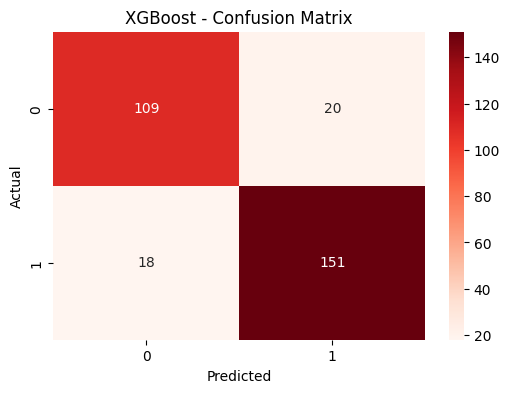

In [165]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')

plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 8. CAT BOOST

In [166]:
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV

cat = CatBoostClassifier(
    verbose=0,
    random_state=42
)

cat_param_grid = {
    'iterations': [100, 200],
    'depth': [4, 6],
    'learning_rate': [0.05, 0.1]
}

cat_grid = GridSearchCV(
    estimator=cat,
    param_grid=cat_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

cat_grid.fit(X_train_processed, y_train)

best_cat = cat_grid.best_estimator_
y_pred = best_cat.predict(X_test_processed)

print("Best CatBoost Params:", cat_grid.best_params_)
score = accuracy_score(y_test, y_pred)
print(score)
print(classification_report(y_test, y_pred))

Best CatBoost Params: {'depth': 6, 'iterations': 200, 'learning_rate': 0.1}
0.87248322147651
              precision    recall  f1-score   support

           0       0.87      0.83      0.85       129
           1       0.87      0.91      0.89       169

    accuracy                           0.87       298
   macro avg       0.87      0.87      0.87       298
weighted avg       0.87      0.87      0.87       298



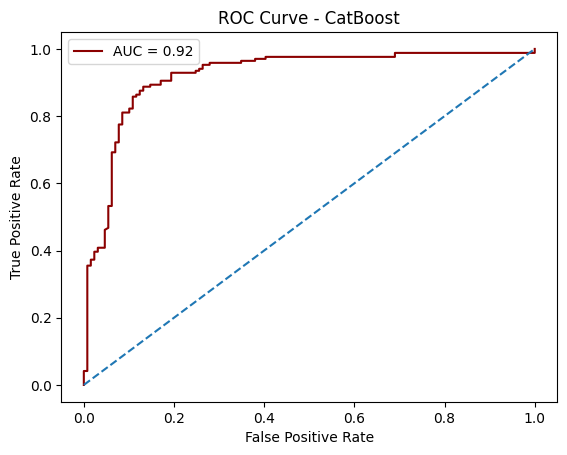

In [167]:
from sklearn.metrics import roc_curve, auc

y_prob = best_cat.predict_proba(X_test_processed)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}", color='darkred')
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - CatBoost")
plt.legend()

plt.show()

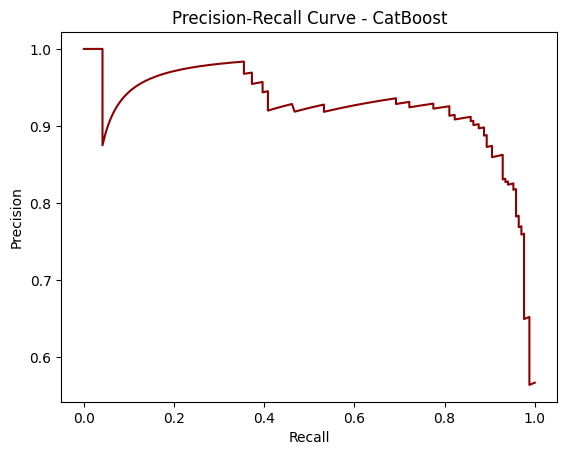

In [168]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision, color='darkred')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - CatBoost")

plt.show()

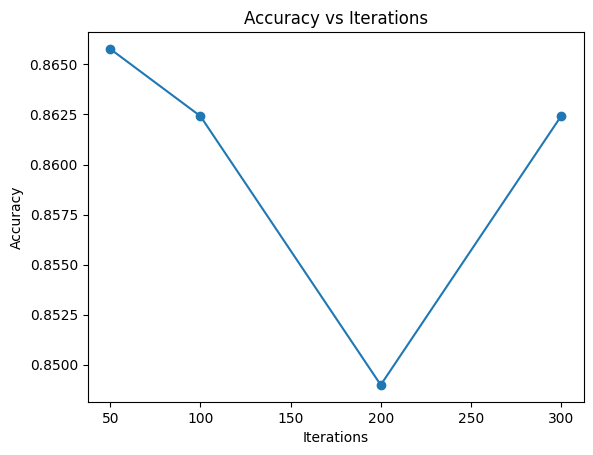

In [169]:
iters = [50, 100, 200, 300]
acc = []

for i in iters:
    model = CatBoostClassifier(iterations=i, verbose=0)
    model.fit(X_train_processed, y_train)
    acc.append(accuracy_score(y_test, model.predict(X_test_processed)))

plt.plot(iters, acc, marker='o')
plt.title("Accuracy vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Accuracy")

plt.show()

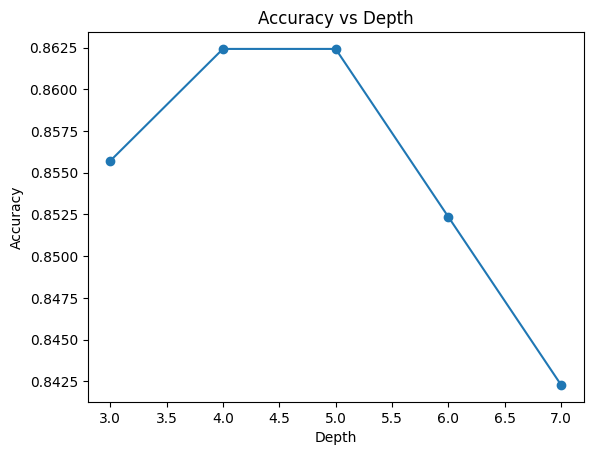

In [170]:
depths = [3, 4, 5, 6, 7]
acc = []

for d in depths:
    model = CatBoostClassifier(depth=d, verbose=0)
    model.fit(X_train_processed, y_train)
    acc.append(accuracy_score(y_test, model.predict(X_test_processed)))

plt.plot(depths, acc, marker='o')
plt.title("Accuracy vs Depth")
plt.xlabel("Depth")
plt.ylabel("Accuracy")

plt.show()

Confusion Matrix

In [171]:
from sklearn.metrics import confusion_matrix
import pandas as pd
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Convert to DataFrame for better readability
cm_df = pd.DataFrame(cm,
index=["Actual 0", "Actual 1"],
columns=["Predicted 0", "Predicted 1"])
print("Confusion Matrix')")
print(cm_df)

Confusion Matrix')
          Predicted 0  Predicted 1
Actual 0          107           22
Actual 1           16          153


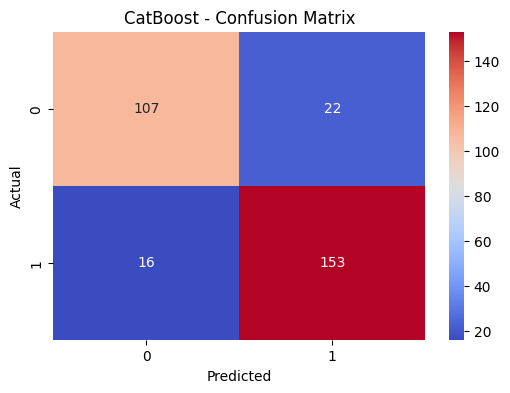

In [172]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')

plt.title("CatBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 9. ADA BOOST

In [173]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV

ada = AdaBoostClassifier(random_state=42)

ada_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.5, 1.0]
}

ada_grid = GridSearchCV(
    estimator=ada,
    param_grid=ada_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

ada_grid.fit(X_train_processed, y_train)

best_ada = ada_grid.best_estimator_

y_pred = best_ada.predict(X_test_processed)

print("Best AdaBoost Params:", ada_grid.best_params_)
score = accuracy_score(y_test, y_pred)
print(score)
print(classification_report(y_test, y_pred))

Best AdaBoost Params: {'learning_rate': 1.0, 'n_estimators': 100}
0.8422818791946308
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       129
           1       0.87      0.85      0.86       169

    accuracy                           0.84       298
   macro avg       0.84      0.84      0.84       298
weighted avg       0.84      0.84      0.84       298



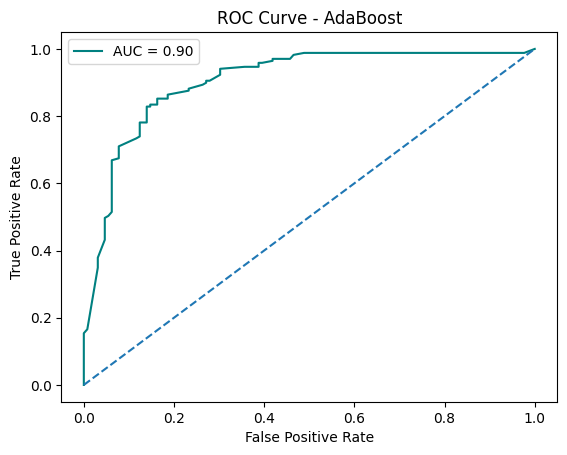

In [174]:
from sklearn.metrics import roc_curve, auc

y_prob = best_ada.predict_proba(X_test_processed)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}", color='teal')
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - AdaBoost")
plt.legend()

plt.show()

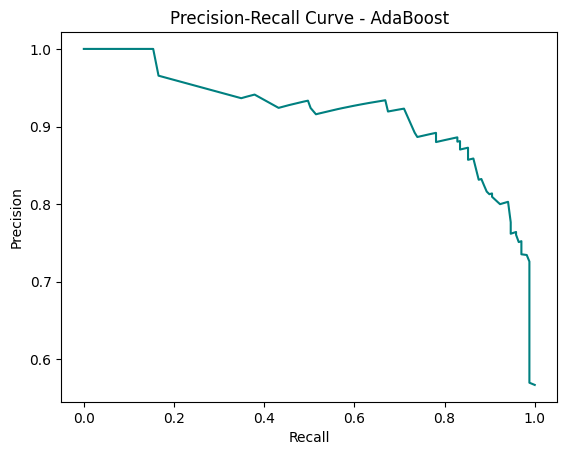

In [175]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision, color='teal')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - AdaBoost")

plt.show()

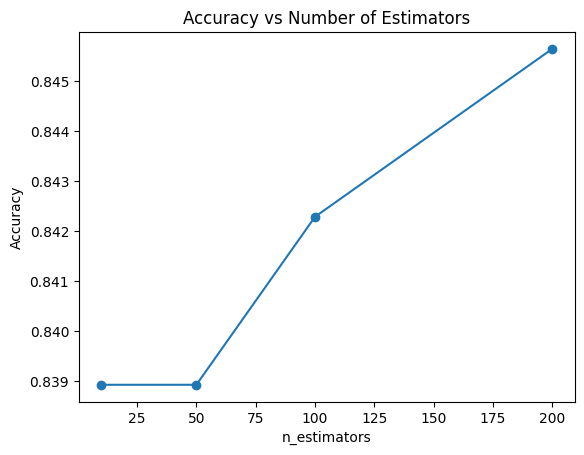

In [176]:
n_values = [10, 50, 100, 200]
acc = []

for n in n_values:
    model = AdaBoostClassifier(n_estimators=n)
    model.fit(X_train_processed, y_train)
    acc.append(accuracy_score(y_test, model.predict(X_test_processed)))

plt.plot(n_values, acc, marker='o')
plt.title("Accuracy vs Number of Estimators")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")

plt.show()

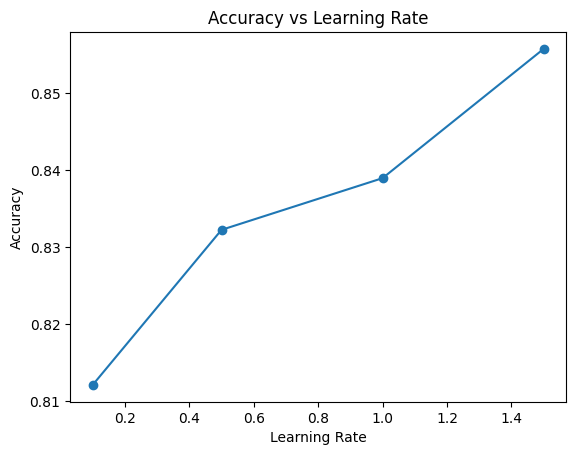

In [177]:
lr_values = [0.1, 0.5, 1.0, 1.5]
acc = []

for lr in lr_values:
    model = AdaBoostClassifier(learning_rate=lr)
    model.fit(X_train_processed, y_train)
    acc.append(accuracy_score(y_test, model.predict(X_test_processed)))

plt.plot(lr_values, acc, marker='o')
plt.title("Accuracy vs Learning Rate")
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")

plt.show()

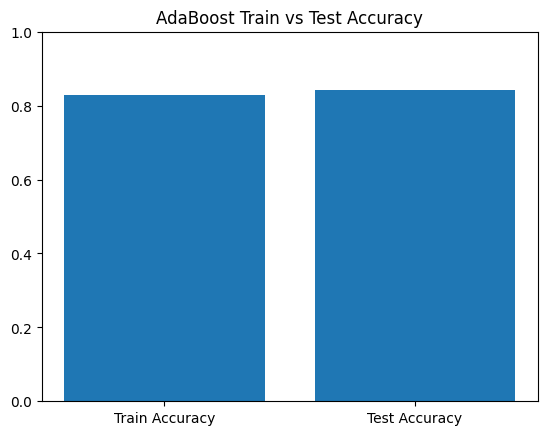

In [178]:
train_acc = accuracy_score(y_train, best_ada.predict(X_train_processed))
test_acc = accuracy_score(y_test, best_ada.predict(X_test_processed))

plt.bar(['Train Accuracy', 'Test Accuracy'], [train_acc, test_acc])
plt.ylim(0,1)
plt.title("AdaBoost Train vs Test Accuracy")

plt.show()

Confusion Matrix

In [179]:
from sklearn.metrics import confusion_matrix
import pandas as pd
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Convert to DataFrame for better readability
cm_df = pd.DataFrame(cm,
index=["Actual 0", "Actual 1"],
columns=["Predicted 0", "Predicted 1"])
print("Confusion Matrix')")
print(cm_df)

Confusion Matrix')
          Predicted 0  Predicted 1
Actual 0          107           22
Actual 1           25          144


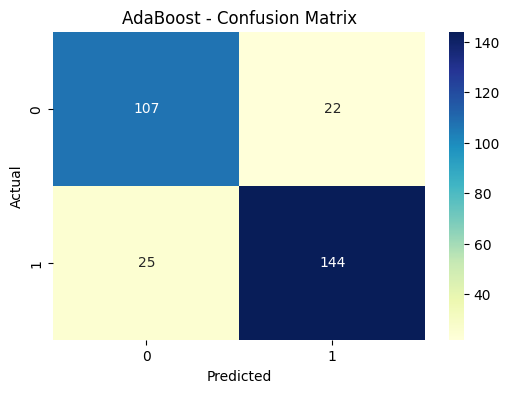

In [180]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')

plt.title("AdaBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 10. GRADIENT DESCENT

In [181]:
gb = GradientBoostingClassifier(random_state=42)

gb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4]  # still works but internally affects trees
}

gb_grid = GridSearchCV(
    estimator=gb,
    param_grid=gb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

gb_grid.fit(X_train_processed, y_train)

best_gb = gb_grid.best_estimator_
y_pred = best_gb.predict(X_test_processed)

print("Best GradientBoost Params:", gb_grid.best_params_)
score = accuracy_score(y_test, y_pred)
print(score)
print(classification_report(y_test, y_pred))

Best GradientBoost Params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}
0.8624161073825504
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       129
           1       0.88      0.88      0.88       169

    accuracy                           0.86       298
   macro avg       0.86      0.86      0.86       298
weighted avg       0.86      0.86      0.86       298



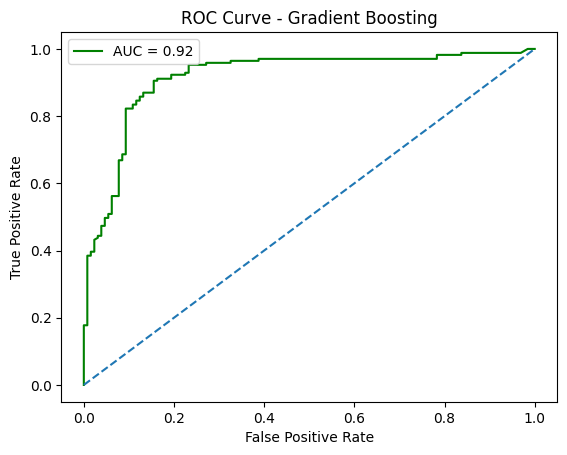

In [182]:
from sklearn.metrics import roc_curve, auc

y_prob = best_gb.predict_proba(X_test_processed)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}", color='green')
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting")
plt.legend()

plt.show()

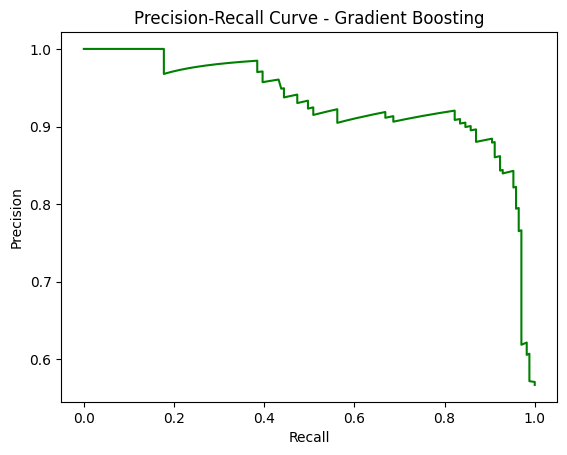

In [183]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision, color='green')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Gradient Boosting")

plt.show()

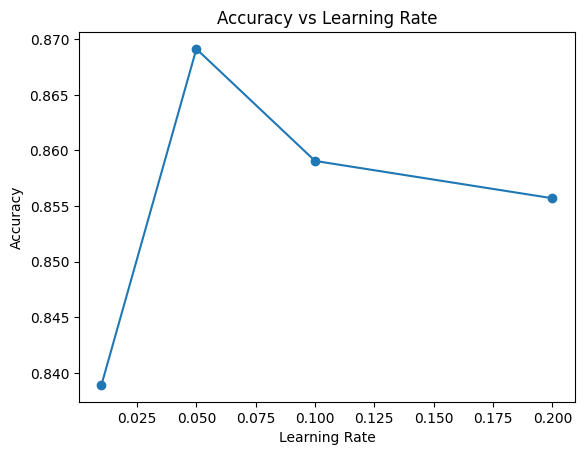

In [184]:
lr_values = [0.01, 0.05, 0.1, 0.2]
acc = []

for lr in lr_values:
    model = GradientBoostingClassifier(learning_rate=lr)
    model.fit(X_train_processed, y_train)
    acc.append(accuracy_score(y_test, model.predict(X_test_processed)))

plt.plot(lr_values, acc, marker='o')
plt.title("Accuracy vs Learning Rate")
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")

plt.show()

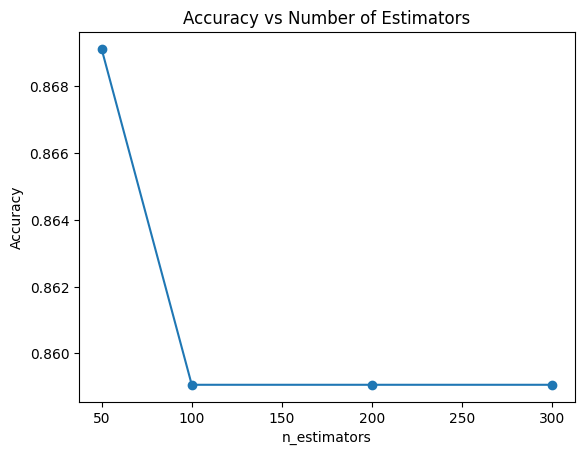

In [185]:
n_values = [50, 100, 200, 300]
acc = []

for n in n_values:
    model = GradientBoostingClassifier(n_estimators=n)
    model.fit(X_train_processed, y_train)
    acc.append(accuracy_score(y_test, model.predict(X_test_processed)))

plt.plot(n_values, acc, marker='o')
plt.title("Accuracy vs Number of Estimators")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")

plt.show()

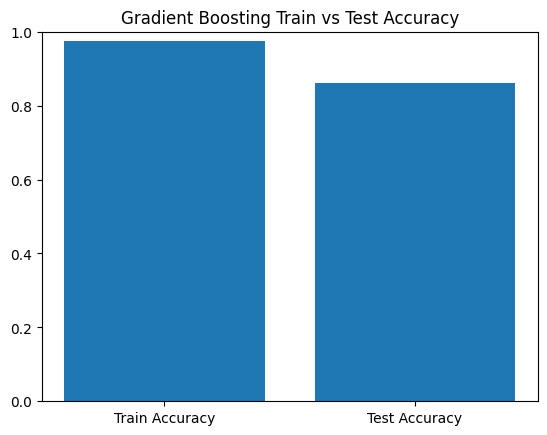

In [186]:
train_acc = accuracy_score(y_train, best_gb.predict(X_train_processed))
test_acc = accuracy_score(y_test, best_gb.predict(X_test_processed))

plt.bar(['Train Accuracy', 'Test Accuracy'], [train_acc, test_acc])
plt.ylim(0,1)
plt.title("Gradient Boosting Train vs Test Accuracy")

plt.show()

Confusion Matrix

In [187]:
from sklearn.metrics import confusion_matrix
import pandas as pd
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Convert to DataFrame for better readability
cm_df = pd.DataFrame(cm,
index=["Actual 0", "Actual 1"],
columns=["Predicted 0", "Predicted 1"])
print("Confusion Matrix')")
print(cm_df)

Confusion Matrix')
          Predicted 0  Predicted 1
Actual 0          109           20
Actual 1           21          148


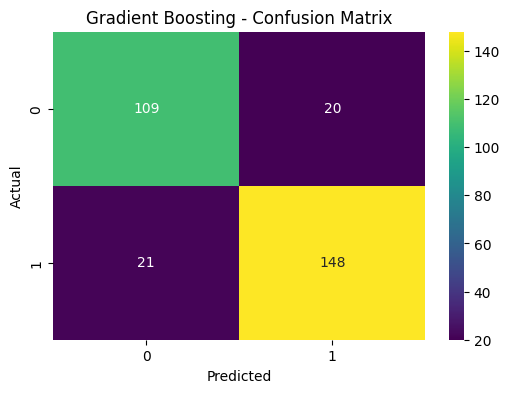

In [188]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis')

plt.title("Gradient Boosting - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Model Comparison Table

In [189]:
results = pd.DataFrame({
    'Model': ['Logistic', 'Naive Bayes', 'KNN', 'SVM', 'Decision Tree',
              'Random Forest', 'XGBoost', 'CatBoost', 'AdaBoost', 'Gradient Boosting'],
    'Accuracy': [0.835, 0.829, 0.903, 0.829, 0.842, 0.866, 0.872, 0.872, 0.842, 0.862]
})

results.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy
2,KNN,0.903
6,XGBoost,0.872
7,CatBoost,0.872
5,Random Forest,0.866
9,Gradient Boosting,0.862
4,Decision Tree,0.842
8,AdaBoost,0.842
0,Logistic,0.835
1,Naive Bayes,0.829
3,SVM,0.829


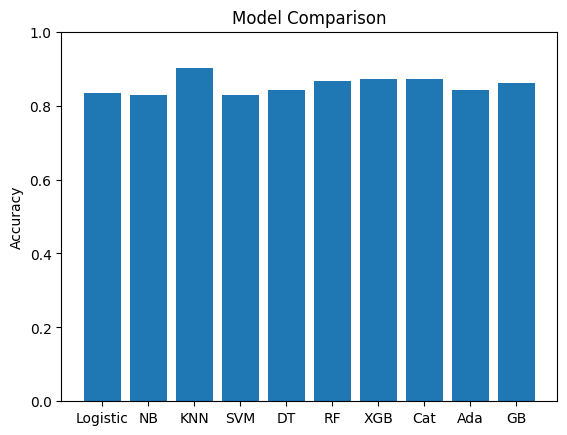

In [191]:
models = ['Logistic', 'NB', 'KNN', 'SVM', 'DT', 'RF', 'XGB', 'Cat', 'Ada', 'GB']
scores = [0.835, 0.829, 0.903, 0.829, 0.842, 0.866, 0.872, 0.872, 0.842, 0.862]
plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)

plt.show()

In [192]:
from sklearn.model_selection import cross_val_score

models = {
    'RF': classifier_random.best_estimator_,
    'XGB': best_xgb,
    'CatBoost': best_cat
}

for name, model in models.items():
    scores = cross_val_score(model, X_train_processed, y_train, cv=5)
    print(f"{name}: {scores.mean():.3f}")

RF: 0.865
XGB: 0.868
CatBoost: 0.877


## Conclusion

Among all models, KNN achieved the highest accuracy (approx. 90%), followed by XGBoost and CatBoost (approx. 87%). Ensemble and boosting methods generally performed better than simple models due to their ability to reduce bias and variance.

In [205]:
import pickle
pickle.dump(best_xgb, open('model.pkl', 'wb'))

In [209]:
import pickle
with open('model.pkl', 'wb') as f:
    pickle.dump({'model': classifier_neighbor.best_estimator_,  # KNN was best at ~90%
                 'preprocessor': preprocessor}, f)